# Measure analysis

##### Imports and params

In [2]:
from __future__ import annotations

import pandas as pd

from pathlib import Path
import matplotlib.pyplot as plt
import openalea.rsml as rsml
from tqdm import tqdm 
from pandarallel import pandarallel

pandarallel.initialize(nb_workers=6, progress_bar=True)

INFO: Pandarallel will run on 6 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [3]:
plt.rcParams.update({
"figure.figsize": (18, 10),
"axes.grid": True,
"grid.linestyle": ":",
"grid.alpha": 0.5,
"axes.titlesize": 14,
"axes.labelsize": 12,
"legend.fontsize": 10,
})

In [4]:
MORPHO_RESULTS = Path("/home/loai/Documents/code/RSMLExtraction/RSA_reconstruction/Method/RootNav2/results_per_plant.csv").expanduser()
PATH_2_LOGS = Path("/home/loai/Documents/code/RSMLExtraction/RSA_reconstruction/Method/RootNav2/log_rootnav2.csv").expanduser()

## Loading database

In [5]:
df_base = pd.read_csv(MORPHO_RESULTS)
df_base.head()

,model,model_name,loss_name,iter,box,metric,time,root_ids,source,value
0,CLDICE,Hourglass,CLDICE,10700,230629PN027,NumberOfOrgans,10,"(1, 3, 10)",Prediction,2.0
1,CLDICE,Hourglass,CLDICE,10700,230629PN027,NumberOfOrgans,10,"(1, 3, 10)",expertized,2.0
2,CLDICE,Hourglass,CLDICE,10700,230629PN027,NumberOfOrgans,10,"(4, 1, 1)",Prediction,1.0
3,CLDICE,Hourglass,CLDICE,10700,230629PN027,NumberOfOrgans,10,"(4, 1, 1)",expertized,1.0
4,CLDICE,Hourglass,CLDICE,10700,230629PN027,NumberOfOrgans,10,"(8, 11, 22)",Prediction,1.0


In [6]:
tqdm.pandas(desc="Processing renaming models")

# rename iter col with epoch
df_base['epoch'] = df_base['iter'] 
df_base = df_base.drop(columns=['iter'], errors='ignore')

# divide model into three columns, model_name, loss_name and epoch
df_base['model_name'] = "Hourglass"  

# remove _number from loss_name
df_base['loss_name'] = df_base['loss_name'].str.replace(r'_\d+', '', regex=True)
df_base.head()

,model,model_name,loss_name,box,metric,time,root_ids,source,value,epoch
0,CLDICE,Hourglass,CLDICE,230629PN027,NumberOfOrgans,10,"(1, 3, 10)",Prediction,2.0,10700
1,CLDICE,Hourglass,CLDICE,230629PN027,NumberOfOrgans,10,"(1, 3, 10)",expertized,2.0,10700
2,CLDICE,Hourglass,CLDICE,230629PN027,NumberOfOrgans,10,"(4, 1, 1)",Prediction,1.0,10700
3,CLDICE,Hourglass,CLDICE,230629PN027,NumberOfOrgans,10,"(4, 1, 1)",expertized,1.0,10700
4,CLDICE,Hourglass,CLDICE,230629PN027,NumberOfOrgans,10,"(8, 11, 22)",Prediction,1.0,10700


In [7]:
# root_ids col is a tuple (_, _, _) drop the middle value and keep the first and last value as a tuple (first, last)
df_base['root_ids'] = df_base['root_ids'].parallel_apply(lambda x: tuple(map(int, x.strip("()").split(",")[0::2])))
df_base.head()

,model,model_name,loss_name,box,metric,time,root_ids,source,value,epoch
0,CLDICE,Hourglass,CLDICE,230629PN027,NumberOfOrgans,10,"(1, 10)",Prediction,2.0,10700
1,CLDICE,Hourglass,CLDICE,230629PN027,NumberOfOrgans,10,"(1, 10)",expertized,2.0,10700
2,CLDICE,Hourglass,CLDICE,230629PN027,NumberOfOrgans,10,"(4, 1)",Prediction,1.0,10700
3,CLDICE,Hourglass,CLDICE,230629PN027,NumberOfOrgans,10,"(4, 1)",expertized,1.0,10700
4,CLDICE,Hourglass,CLDICE,230629PN027,NumberOfOrgans,10,"(8, 22)",Prediction,1.0,10700


In [8]:
# get all boxes in the df_base
boxes = df_base['box'].unique()
path_2_rsmls = "/home/loai/Images/DataTest/UC1/UC1_OLD/"
# foe each box, path_2_rsmls + box + "/61_graph_expertized.rsml"
for box in boxes:
    rsml_path = Path(path_2_rsmls) / f"{box}/61_graph_expertized.rsml"
    graph = rsml.rsml2mtg(str(rsml_path))
    metadata = graph.graph_properties().get('metadata', {})
        
    print(f"Processing box: {box} with metadata: {metadata}")
    obs_hours = [float(h) for h in metadata.get('observation-hours', "")]
    
    mask = df_base['box'] == box
    #df_base.loc[mask, 'pixel_size'] = pixel_size * 1e-3 # convert to mm
    
    def map_time(idx):
        try:
            return obs_hours[int(idx) - 1]
        except (IndexError, ValueError):
            return None
    df_base.loc[mask, 'time_hours'] = df_base.loc[mask, 'time'].parallel_apply(map_time)
df_base.head()

Processing box: 230629PN027 with metadata: {'version': 1.4, 'unit': 'pixel(um)', 'last-modified': datetime.datetime(2023, 7, 24, 17, 55, 28), 'software': 'RootSystemTracker', 'user': 'Unknown', 'file-key': '61_graph_expertized', 'observation-hours': [0.0, 13.6579, 19.6552, 25.6635, 31.6582, 37.6575, 43.6521, 49.6545, 55.6573, 61.6561, 67.6573, 73.6561, 79.6611, 85.6577, 91.6564, 95.4297, 101.4296, 107.4292, 113.4344, 119.4335, 125.4326, 131.4307, 137.4272, 143.4349, 158.6091, 164.6043, 170.5996, 176.5987, 182.6015], 'image': {'label': '61_graph_expertized', 'sha256': 'Nothing there', 'resolution': 76.0}, 'resolution': 76.0, 'functions': ['time', 'time_hours']}


Processing box: 230629PN018 with metadata: {'version': 1.4, 'unit': 'pixel(um)', 'last-modified': datetime.datetime(2023, 7, 21, 15, 22, 55), 'software': 'RootSystemTracker', 'user': 'Unknown', 'file-key': '61_graph_expertized', 'observation-hours': [0.0, 13.6585, 19.6568, 25.6601, 31.656, 37.6551, 43.6522, 49.6531, 55.6558, 61.6558, 67.6548, 73.6547, 79.6579, 85.6561, 91.656, 95.4298, 101.4304, 107.429, 113.4349, 119.4302, 125.4303, 131.4303, 137.4273, 143.4306, 158.6076, 164.6032, 170.5991, 176.5989, 182.6003], 'image': {'label': '61_graph_expertized', 'sha256': 'Nothing there', 'resolution': 76.0}, 'resolution': 76.0, 'functions': ['time', 'time_hours']}


Processing box: 230629PN008 with metadata: {'version': 1.4, 'unit': 'pixel(um)', 'last-modified': datetime.datetime(2023, 7, 20, 15, 7, 37), 'software': 'RootSystemTracker', 'user': 'Unknown', 'file-key': '61_graph_expertized', 'observation-hours': [0.0, 13.657, 19.6561, 25.6567, 31.6556, 37.6559, 43.6545, 49.6536, 55.6563, 61.6567, 67.6553, 73.6551, 79.6543, 85.6566, 91.6552, 95.4306, 101.4313, 107.4311, 113.4316, 119.4308, 125.4299, 131.4292, 137.4283, 143.4296, 158.6052, 164.5999, 170.6004, 176.5987, 182.5989], 'image': {'label': '61_graph_expertized', 'sha256': 'Nothing there', 'resolution': 76.0}, 'resolution': 76.0, 'functions': ['time', 'time_hours']}


Processing box: 230629PN010 with metadata: {'version': 1.4, 'unit': 'pixel(um)', 'last-modified': datetime.datetime(2023, 7, 20, 15, 59, 43), 'software': 'RootSystemTracker', 'user': 'Unknown', 'file-key': '61_graph_expertized', 'observation-hours': [0.0, 13.6571, 19.6551, 25.6568, 31.6557, 37.6549, 43.6534, 49.6535, 55.6554, 61.6557, 67.6543, 73.6542, 79.6554, 85.6568, 91.6541, 95.4295, 101.4302, 107.43, 113.4316, 119.4308, 125.4289, 131.4292, 137.4273, 143.4294, 158.6042, 164.6, 170.5996, 176.5985, 182.599], 'image': {'label': '61_graph_expertized', 'sha256': 'Nothing there', 'resolution': 76.0}, 'resolution': 76.0, 'functions': ['time', 'time_hours']}


Processing box: 230629PN014 with metadata: {'version': 1.4, 'unit': 'pixel(um)', 'last-modified': datetime.datetime(2023, 7, 20, 17, 48, 37), 'software': 'RootSystemTracker', 'user': 'Unknown', 'file-key': '61_graph_expertized', 'observation-hours': [0.0, 13.6584, 19.6549, 25.659, 31.6558, 37.656, 43.6534, 49.6539, 55.6557, 61.6559, 67.6546, 73.6555, 79.6566, 85.657, 91.6552, 95.4306, 101.4312, 107.4301, 113.4347, 119.431, 125.4302, 131.4304, 137.4272, 143.4305, 158.6075, 164.601, 170.5999, 176.5988, 182.6001], 'image': {'label': '61_graph_expertized', 'sha256': 'Nothing there', 'resolution': 76.0}, 'resolution': 76.0, 'functions': ['time', 'time_hours']}


...

Processing box: 230629PN012 with metadata: {'version': 1.4, 'unit': 'pixel(um)', 'last-modified': datetime.datetime(2023, 7, 20, 17, 14, 30), 'software': 'RootSystemTracker', 'user': 'Unknown', 'file-key': '61_graph_expertized', 'observation-hours': [0.0, 13.6573, 19.655, 25.658, 31.6558, 37.6549, 43.6534, 49.6538, 55.6554, 61.6557, 67.6546, 73.6552, 79.6565, 85.6569, 91.6551, 95.4305, 101.4303, 107.4301, 113.4335, 119.4309, 125.43, 131.4293, 137.4273, 143.4305, 158.6054, 164.601, 170.5997, 176.5986, 182.6001], 'image': {'label': '61_graph_expertized', 'sha256': 'Nothing there', 'resolution': 76.0}, 'resolution': 76.0, 'functions': ['time', 'time_hours']}


Processing box: 230629PN024 with metadata: {'version': 1.4, 'unit': 'pixel(um)', 'last-modified': datetime.datetime(2023, 7, 24, 17, 27, 38), 'software': 'RootSystemTracker', 'user': 'Unknown', 'file-key': '61_graph_expertized', 'observation-hours': [0.0, 13.6589, 19.6561, 25.6626, 31.6573, 37.6567, 43.6522, 49.6546, 55.6562, 61.6562, 67.6571, 73.6561, 79.6591, 85.6567, 91.6572, 95.4308, 101.4306, 107.4292, 113.4354, 119.4316, 125.4317, 131.4308, 137.4283, 143.4339, 158.6099, 164.6055, 170.6005, 176.5987, 182.6026], 'image': {'label': '61_graph_expertized', 'sha256': 'Nothing there', 'resolution': 76.0}, 'resolution': 76.0, 'functions': ['time', 'time_hours']}


Processing box: 230629PN031 with metadata: {'version': 1.4, 'unit': 'pixel(um)', 'last-modified': datetime.datetime(2023, 7, 25, 11, 41, 9), 'software': 'RootSystemTracker', 'user': 'Unknown', 'file-key': '61_graph_expertized', 'observation-hours': [0.0, 13.6601, 19.657, 25.6639, 31.6593, 37.6596, 43.653, 49.6564, 55.6596, 61.6571, 67.6586, 73.6592, 79.6631, 85.659, 91.6573, 95.4306, 101.4296, 107.4302, 113.4347, 119.4338, 125.4338, 131.4308, 137.4281, 157.5067, 159.2198, 164.6053, 170.5999, 181.391, 182.6027], 'image': {'label': '61_graph_expertized', 'sha256': 'Nothing there', 'resolution': 76.0}, 'resolution': 76.0, 'functions': ['time', 'time_hours']}


Processing box: 230629PN019 with metadata: {'version': 1.4, 'unit': 'pixel(um)', 'last-modified': datetime.datetime(2023, 7, 21, 15, 40, 22), 'software': 'RootSystemTracker', 'user': 'Unknown', 'file-key': '61_graph_expertized', 'observation-hours': [0.0, 13.6586, 19.6567, 25.6602, 31.6559, 37.6552, 43.6521, 49.654, 55.6558, 61.6558, 67.6548, 73.6547, 79.6579, 85.6561, 91.6569, 95.4306, 101.4303, 107.429, 113.4358, 119.4311, 125.4303, 131.4302, 137.4283, 143.4315, 158.6085, 164.6031, 170.599, 176.5989, 182.6003], 'image': {'label': '61_graph_expertized', 'sha256': 'Nothing there', 'resolution': 76.0}, 'resolution': 76.0, 'functions': ['time', 'time_hours']}


,model,model_name,loss_name,box,metric,time,root_ids,source,value,epoch,time_hours
0,CLDICE,Hourglass,CLDICE,230629PN027,NumberOfOrgans,10,"(1, 10)",Prediction,2.0,10700,61.6561
1,CLDICE,Hourglass,CLDICE,230629PN027,NumberOfOrgans,10,"(1, 10)",expertized,2.0,10700,61.6561
2,CLDICE,Hourglass,CLDICE,230629PN027,NumberOfOrgans,10,"(4, 1)",Prediction,1.0,10700,61.6561
3,CLDICE,Hourglass,CLDICE,230629PN027,NumberOfOrgans,10,"(4, 1)",expertized,1.0,10700,61.6561
4,CLDICE,Hourglass,CLDICE,230629PN027,NumberOfOrgans,10,"(8, 22)",Prediction,1.0,10700,61.6561


In [9]:
combination_counts = df_base.groupby(['model', 'loss_name']).size().reset_index(name='counts')

combination_counts = combination_counts.groupby(['model', 'loss_name']).agg({'counts': 'sum'}).reset_index()
print(combination_counts)

    model loss_name   counts
0      CE        CE  6776156
1  CLDICE    CLDICE  2870968
2    DICE      DICE  8207826


In [10]:
# print all metrics 
print(df_base['metric'].unique())

<ArrowStringArray>
[      'NumberOfOrgans',      'TotalRootLength', 'NumberOfLateralRoots',
     'Convex_Area_Hull',          'RootDensity',    'PrimaryRootLength',
    'LateralRootLength']
Length: 7, dtype: str


In [11]:
# order by model_name, loss_name, epoch, box and time
df_base = df_base.sort_values(by=['model_name', 'loss_name', 'epoch', 'box', 'time', 'time_hours'])

# pivot on source "source" and value is "value" column 
df_base = df_base.pivot_table(index=['model_name', 'loss_name', 'epoch', 'box', 'time', 'time_hours', 'root_ids', 'metric'], columns='source', values='value').reset_index()

df_base.head()


source,model_name,loss_name,epoch,box,time,time_hours,root_ids,metric,Prediction,expertized
0,Hourglass,CE,100,230629PN006,0,182.6007,"(1, 31)",Convex_Area_Hull,2.993685,4.069192
1,Hourglass,CE,100,230629PN006,0,182.6007,"(1, 31)",LateralRootLength,0.000000,0.000000
2,Hourglass,CE,100,230629PN006,0,182.6007,"(1, 31)",NumberOfLateralRoots,0.000000,0.000000
3,Hourglass,CE,100,230629PN006,0,182.6007,"(1, 31)",NumberOfOrgans,1.000000,1.000000
4,Hourglass,CE,100,230629PN006,0,182.6007,"(1, 31)",PrimaryRootLength,13.401898,14.400807


In [12]:
combination_counts = df_base.groupby(['model_name', 'loss_name']).size().reset_index(name='counts')
print(combination_counts)

  model_name loss_name   counts
0  Hourglass        CE  3388078
1  Hourglass    CLDICE  1435397
2  Hourglass      DICE  4103913


In [13]:
# metrcis should be column and not rows, so we need to pivot the table
df_plant = df_base.pivot(index=['model_name', 'loss_name', 'epoch', 'box', 'time', 'time_hours', 'root_ids'], columns="metric", values="Prediction").reset_index()
df_plant.head()

metric,model_name,loss_name,epoch,box,time,time_hours,root_ids,Convex_Area_Hull,LateralRootLength,NumberOfLateralRoots,NumberOfOrgans,PrimaryRootLength,RootDensity,TotalRootLength
0,Hourglass,CE,100,230629PN006,0,182.6007,"(1, 31)",2.993685,0.000000,0.0,1.0,13.401898,4.476723,13.401898
1,Hourglass,CE,100,230629PN006,0,182.6007,"(3, 23)",3.281607,0.000000,0.0,1.0,13.823011,4.212268,13.823011
2,Hourglass,CE,100,230629PN006,0,182.6007,"(5, 9)",7.991374,0.000000,0.0,1.0,16.544257,2.070264,16.544257
3,Hourglass,CE,100,230629PN006,0,182.6007,"(7, 1)",6.751225,25.490263,0.0,3.0,11.374041,5.460387,36.864305
4,Hourglass,CE,100,230629PN006,0,182.6007,"(11, 21)",3.596673,0.000000,0.0,1.0,11.761601,3.270134,11.761601


In [14]:
df_plant_gt = df_base.pivot(index=['model_name', 'loss_name', 'epoch', 'box', 'time', 'time_hours', 'root_ids'], columns="metric", values="expertized").reset_index()

df_plant_gt.head()

metric,model_name,loss_name,epoch,box,time,time_hours,root_ids,Convex_Area_Hull,LateralRootLength,NumberOfLateralRoots,NumberOfOrgans,PrimaryRootLength,RootDensity,TotalRootLength
0,Hourglass,CE,100,230629PN006,0,182.6007,"(1, 31)",4.069192,0.0,0.0,1.0,14.400807,3.538984,14.400807
1,Hourglass,CE,100,230629PN006,0,182.6007,"(3, 23)",3.843928,0.0,0.0,1.0,13.453554,3.499949,13.453554
2,Hourglass,CE,100,230629PN006,0,182.6007,"(5, 9)",8.435848,0.0,0.0,1.0,16.337364,1.936659,16.337364
3,Hourglass,CE,100,230629PN006,0,182.6007,"(7, 1)",8.505160,0.0,0.0,1.0,13.498684,1.587117,13.498684
4,Hourglass,CE,100,230629PN006,0,182.6007,"(11, 21)",4.993352,0.0,0.0,1.0,13.629917,2.729613,13.629917


In [15]:
def process_plant_kinematics(df):
    metadata_cols = ['model_name', 'loss_name', 'epoch', 'box', 'time', 'time_hours', 'root_ids']
    no_speed_cols = ['NumberOfOrgans', 'NumberOfLateralRoots', 'Intercept_curve_Area']
    metrics = [c for c in df.columns if c not in metadata_cols or c in no_speed_cols]
    
    df = df.sort_values(by=['model_name', 'loss_name', 'epoch', 'box', 'root_ids', 'time_hours'])
    
    grouper = df.groupby(['model_name', 'loss_name', 'epoch', 'box', 'root_ids'])
    
    for metric in metrics:
        speed_col = f"{metric}_speed"
        df[speed_col] = grouper[metric].diff() / grouper['time_hours'].diff()
        
        accel_col = f"{metric}_acceleration"
        df[accel_col] = grouper[speed_col].diff() / grouper['time_hours'].diff()
        
    return df

# Apply to your three dataframes
df_plant = process_plant_kinematics(df_plant)
df_plant_gt = process_plant_kinematics(df_plant_gt)

# Preview results for one metric (e.g., 'length')
df_plant.head()

metric,model_name,loss_name,epoch,box,time,time_hours,root_ids,Convex_Area_Hull,LateralRootLength,NumberOfLateralRoots,...,NumberOfLateralRoots_speed,NumberOfLateralRoots_acceleration,NumberOfOrgans_speed,NumberOfOrgans_acceleration,PrimaryRootLength_speed,PrimaryRootLength_acceleration,RootDensity_speed,RootDensity_acceleration,TotalRootLength_speed,TotalRootLength_acceleration
55,Hourglass,CE,100,230629PN006,11,67.6561,"(1, 1)",14.204726,27.472412,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60,Hourglass,CE,100,230629PN006,12,73.6559,"(1, 1)",17.984440,27.630217,4.0,...,-0.333344,NaN,-0.333344,NaN,0.015569,NaN,-0.071880,NaN,0.041870,NaN
80,Hourglass,CE,100,230629PN006,16,95.4315,"(1, 1)",33.953270,32.723348,6.0,...,0.091846,0.019526,0.091846,0.019526,-0.002722,-0.000840,-0.029633,0.001940,0.231170,0.008693
130,Hourglass,CE,100,230629PN006,26,164.6010,"(1, 1)",128.487728,61.349611,9.0,...,0.043372,-0.000701,0.057829,-0.000492,-0.031295,-0.000413,-0.008106,0.000311,0.382561,0.002189
50,Hourglass,CE,100,230629PN006,10,61.6565,"(1, 21)",26.294787,0.346156,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Logs

In [16]:
df_logs_tb = pd.read_csv(PATH_2_LOGS)
df_logs_tb.head()

,Val_Binary/Betti1_abs,Val_Binary/F4_Score,Val_Binary/Precision,Val_Class_IoU/Class_0_IoU,Val_Loss/Dice,Val_Class_IoU/Class_4_IoU,_timestamp,Validation/Prediction_Example,Val_Binary/IoU,Val_Binary/Dice,...,Val_Binary/Recall,Val_Multi-Class/class_5_iou,Val_Binary/Normalized_Mutual_Info,Val_Binary/Hausdorff95,_runtime,Val_Multi-Class/class_2_iou,run_name,runtime,Train/Loss_Seg_dice,Train/Loss_Seg_cldice_dice
0,NaN,NaN,NaN,NaN,NaN,NaN,1.774133e+09,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,105.572346,NaN,run_60305_cfg_root_train_ce,71855.445346,NaN,NaN
1,5.497794,0.939253,0.531337,0.974199,0.775902,0.323716,1.774133e+09,{'sha256': '4f4e0bcc1d8da0ff9ba698540d711716f6...,0.566042,0.721624,...,0.986672,0.222086,0.566333,0.750110,178.132865,0.382081,run_60305_cfg_root_train_ce,71855.445346,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,1.774133e+09,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,323.411588,NaN,run_60305_cfg_root_train_ce,71855.445346,NaN,NaN
3,3.029779,0.947959,0.593711,0.980268,0.651423,0.508617,1.774133e+09,"{'height': 512, 'width': 512, '_type': 'image-...",0.617219,0.762581,...,0.984720,0.251822,0.615386,0.197908,384.574470,0.460887,run_60305_cfg_root_train_ce,71855.445346,NaN,NaN
4,3.847794,0.942210,0.588442,0.976683,0.619374,0.534934,1.774133e+09,"{'_type': 'image-file', 'format': 'png', 'path...",0.612990,0.759180,...,0.979048,0.281767,0.606165,0.259125,488.463447,0.350958,run_60305_cfg_root_train_ce,71855.445346,NaN,NaN


In [17]:

# rename iter col with epoch
df_logs_tb['epoch'] = df_logs_tb['_step']
df_logs_tb = df_logs_tb.drop(columns=['_step'], errors='ignore')

# rename run_name into loss 
df_logs_tb['loss'] = df_logs_tb['run_name']

# Add a column called model always equal to Hourglass
df_logs_tb['model'] = 'Hourglass'
# drop runtime, run_name, run
df_logs_tb = df_logs_tb.drop(columns=['runtime', 'run_name', 'run'], errors='ignore')

df_logs_tb.head()

,Val_Binary/Betti1_abs,Val_Binary/F4_Score,Val_Binary/Precision,Val_Class_IoU/Class_0_IoU,Val_Loss/Dice,Val_Class_IoU/Class_4_IoU,_timestamp,Validation/Prediction_Example,Val_Binary/IoU,Val_Binary/Dice,...,Val_Multi-Class/class_5_iou,Val_Binary/Normalized_Mutual_Info,Val_Binary/Hausdorff95,_runtime,Val_Multi-Class/class_2_iou,Train/Loss_Seg_dice,Train/Loss_Seg_cldice_dice,epoch,loss,model
0,NaN,NaN,NaN,NaN,NaN,NaN,1.774133e+09,NaN,NaN,NaN,...,NaN,NaN,NaN,105.572346,NaN,NaN,NaN,50,run_60305_cfg_root_train_ce,Hourglass
1,5.497794,0.939253,0.531337,0.974199,0.775902,0.323716,1.774133e+09,{'sha256': '4f4e0bcc1d8da0ff9ba698540d711716f6...,0.566042,0.721624,...,0.222086,0.566333,0.750110,178.132865,0.382081,NaN,NaN,100,run_60305_cfg_root_train_ce,Hourglass
2,NaN,NaN,NaN,NaN,NaN,NaN,1.774133e+09,NaN,NaN,NaN,...,NaN,NaN,NaN,323.411588,NaN,NaN,NaN,250,run_60305_cfg_root_train_ce,Hourglass
3,3.029779,0.947959,0.593711,0.980268,0.651423,0.508617,1.774133e+09,"{'height': 512, 'width': 512, '_type': 'image-...",0.617219,0.762581,...,0.251822,0.615386,0.197908,384.574470,0.460887,NaN,NaN,300,run_60305_cfg_root_train_ce,Hourglass
4,3.847794,0.942210,0.588442,0.976683,0.619374,0.534934,1.774133e+09,"{'_type': 'image-file', 'format': 'png', 'path...",0.612990,0.759180,...,0.281767,0.606165,0.259125,488.463447,0.350958,NaN,NaN,400,run_60305_cfg_root_train_ce,Hourglass


In [18]:

# replace CE by Cross-entropy, DICE by DICE and CLDICE by Multi-class-CLDICE
df_plant['loss_name'] = df_plant['loss_name'].replace({
    'CE': 'Cross-entropy',
    'DICE': 'DICE',
    'CLDICE': 'Multi-class-CLDICE'
})

df_plant_gt['loss_name'] = df_plant_gt['loss_name'].replace({
    'CE': 'Cross-entropy',
    'DICE': 'DICE',
    'CLDICE': 'Multi-class-CLDICE'
})


df_logs_tb['loss'] = df_logs_tb['loss'].replace({
    'run_60305_cfg_root_train_ce': 'Cross-entropy',
    'run_55804_cfg_root_train_dice': 'DICE',
    'run_68593_cfg_root_train_cldice': 'Multi-class-CLDICE'
})
print(f'Unique losses: {df_plant["loss_name"].unique()}')
print(f'Unique losses: {df_logs_tb["loss"].unique()}')

Unique losses: <ArrowStringArray>
['Cross-entropy', 'Multi-class-CLDICE', 'DICE']
Length: 3, dtype: str
Unique losses: <ArrowStringArray>
['Cross-entropy', 'DICE', 'Multi-class-CLDICE']
Length: 3, dtype: str


## Prepare diff datasets

In [19]:
# all columns that are not model_name, loss_name, epoch, box and time are metrics
metric_columns = [col for col in df_plant.columns if col not in ['model_name', 'loss_name', 'epoch', "box", "time", 'time_hours', "root_ids"]]
df_diff = df_plant_gt.copy()

# print type of every column in df_plant_gt and df_plant
print("df_plant_gt column types:")
print(df_plant_gt.dtypes)
print("\ndf_plant column types:")
print(df_plant.dtypes)

for metric in metric_columns:
    df_diff[f"{metric}_signed_err"] = df_plant[metric] - df_plant_gt[metric]
    
    df_diff[f"{metric}_abs_err"] = df_diff[f"{metric}_signed_err"].abs()
    
    floatgt = abs(df_plant_gt[metric].astype(float)) # yolo les na
    df_diff[f'{metric}_rel_err'] = (df_diff[f"{metric}_abs_err"] / (floatgt + 1e-9)).clip(lower=1)
    
    floatpred = abs(df_plant[metric].astype(float)) # yolo les na
    df_diff[f"{metric}_smape_err"] = 2 * df_diff[f"{metric}_abs_err"] / (floatpred + floatgt + 1e-9)
    
    
    
# drop TimeStep_signed_err, TimeStep_abs_err and TimeStep_rel_err if they exist
df_diff = df_diff.drop(columns=metric_columns)

# rename columns model_name, loss_name into model, loss
df_diff = df_diff.rename(columns={'model_name': 'model', 'loss_name': 'loss'})

#df_diff.dropna(inplace=True)

print("Available loss names:", df_diff['loss'].unique().tolist())

df_diff.head()

df_plant_gt column types:
metric
model_name                               str
loss_name                                str
epoch                                  int64
box                                      str
time                                   int64
time_hours                           float64
root_ids                              object
Convex_Area_Hull                     float64
LateralRootLength                    float64
NumberOfLateralRoots                 float64
NumberOfOrgans                       float64
PrimaryRootLength                    float64
RootDensity                          float64
TotalRootLength                      float64
Convex_Area_Hull_speed               float64
Convex_Area_Hull_acceleration        float64
LateralRootLength_speed              float64
LateralRootLength_acceleration       float64
NumberOfLateralRoots_speed           float64
NumberOfLateralRoots_acceleration    float64
NumberOfOrgans_speed                 float64
NumberOfOrgans_acceler

metric,model,loss,epoch,box,time,time_hours,root_ids,Convex_Area_Hull_signed_err,Convex_Area_Hull_abs_err,Convex_Area_Hull_rel_err,...,RootDensity_acceleration_rel_err,RootDensity_acceleration_smape_err,TotalRootLength_speed_signed_err,TotalRootLength_speed_abs_err,TotalRootLength_speed_rel_err,TotalRootLength_speed_smape_err,TotalRootLength_acceleration_signed_err,TotalRootLength_acceleration_abs_err,TotalRootLength_acceleration_rel_err,TotalRootLength_acceleration_smape_err
55,Hourglass,Cross-entropy,100,230629PN006,11,67.6561,"(1, 1)",-24.000626,24.000626,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60,Hourglass,Cross-entropy,100,230629PN006,12,73.6559,"(1, 1)",-23.181112,23.181112,1.0,...,NaN,NaN,-0.247915,0.247915,1.0,1.495016,NaN,NaN,NaN,NaN
80,Hourglass,Cross-entropy,100,230629PN006,16,95.4315,"(1, 1)",-24.756882,24.756882,1.0,...,24.624786,1.999999,-0.145454,0.145454,1.0,0.478631,0.004705,0.004705,1.179905,0.742101
130,Hourglass,Cross-entropy,100,230629PN006,26,164.6010,"(1, 1)",-34.863328,34.863328,1.0,...,32.231766,1.883155,-0.080345,0.080345,1.0,0.190061,0.000941,0.000941,1.000000,0.547883
50,Hourglass,Cross-entropy,100,230629PN006,10,61.6565,"(1, 21)",-2.885565,2.885565,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
# %% [markdown]
# ## Minimum Possible Error per Root (Best-case scenario with ALL Model/Loss/Epoch infos)

# %%
import ast
import pandas as pd
from IPython.display import display

# 1. Extraire proprement la valeur Y (yvalue)
def get_y(root_id):
    if isinstance(root_id, str):
        try: return ast.literal_eval(root_id)[1]
        except: return root_id
    elif isinstance(root_id, (tuple, list)) and len(root_id) > 1:
        return root_id[1]
    return root_id

df_diff_time_28 = df_diff[df_diff['time'] == 28].copy()
df_diff_time_28['yvalue'] = df_diff_time_28['root_ids'].parallel_apply(get_y)

# 2. Identifier les colonnes d'erreur
error_cols = [col for col in df_diff_time_28.columns if '_abs_err' in col]

# 3. "Déplier" le dataframe : format large -> format long
df_melted = df_diff_time_28.melt(
    id_vars=['box', 'yvalue', 'model', 'loss', 'epoch'], 
    value_vars=error_cols,
    var_name='metric',
    value_name='error_value'
)

# 4. Trouver TOUTES les lignes contenant l'erreur minimale
# On calcule le minimum pour chaque groupe et on l'ajoute comme colonne temporaire
df_melted['min_error'] = df_melted.groupby(['box', 'yvalue', 'metric'])['error_value'].transform('min')

# On filtre pour garder toutes les lignes (epochs, models, losses) qui atteignent ce minimum
df_min_possible = df_melted[df_melted['error_value'] == df_melted['min_error']].copy()

# On supprime la colonne temporaire
df_min_possible = df_min_possible.drop(columns=['min_error'])

# 5. Trier pour faciliter la lecture (par racine, métrique, modèle, epoch)
df_min_possible = df_min_possible.sort_values(by=['box', 'yvalue', 'metric', 'model', 'loss', 'epoch']).reset_index(drop=True)

# Affichage du tableau filtré sur NumberOfOrgans_abs_err
display(df_min_possible[df_min_possible["metric"] == "NumberOfOrgans_abs_err"])

,box,yvalue,model,loss,epoch,metric,error_value
306,230629PN006,1,Hourglass,Cross-entropy,600,NumberOfOrgans_abs_err,0.0
307,230629PN006,1,Hourglass,Cross-entropy,800,NumberOfOrgans_abs_err,0.0
308,230629PN006,1,Hourglass,Cross-entropy,1700,NumberOfOrgans_abs_err,0.0
309,230629PN006,1,Hourglass,Cross-entropy,2000,NumberOfOrgans_abs_err,0.0
310,230629PN006,1,Hourglass,Cross-entropy,2800,NumberOfOrgans_abs_err,0.0
...,...,...,...,...,...,...,...
11579,230629PN031,84,Hourglass,Cross-entropy,56800,NumberOfOrgans_abs_err,0.0
11580,230629PN031,84,Hourglass,Cross-entropy,58400,NumberOfOrgans_abs_err,0.0
11581,230629PN031,84,Hourglass,Cross-entropy,60000,NumberOfOrgans_abs_err,0.0
11582,230629PN031,84,Hourglass,Cross-entropy,61300,NumberOfOrgans_abs_err,0.0


## Merge with logs

In [21]:
duplicates_mask = df_logs_tb.duplicated(subset=['model', 'loss', 'epoch'], keep=False)
df_duplicates = df_logs_tb[duplicates_mask]

df_duplicates = df_duplicates.sort_values(by=['model', 'loss', 'epoch'])

print(f"Nombre total de lignes dupliquées : {len(df_duplicates)}")
print("Aperçu des doublons :")
df_duplicates.head(20)

Nombre total de lignes dupliquées : 192000
Aperçu des doublons :


,Val_Binary/Betti1_abs,Val_Binary/F4_Score,Val_Binary/Precision,Val_Class_IoU/Class_0_IoU,Val_Loss/Dice,Val_Class_IoU/Class_4_IoU,_timestamp,Validation/Prediction_Example,Val_Binary/IoU,Val_Binary/Dice,...,Val_Multi-Class/class_5_iou,Val_Binary/Normalized_Mutual_Info,Val_Binary/Hausdorff95,_runtime,Val_Multi-Class/class_2_iou,Train/Loss_Seg_dice,Train/Loss_Seg_cldice_dice,epoch,loss,model
0,NaN,NaN,NaN,NaN,NaN,NaN,1.774133e+09,NaN,NaN,NaN,...,NaN,NaN,NaN,105.572346,NaN,NaN,NaN,50,Cross-entropy,Hourglass
1000,NaN,NaN,NaN,NaN,NaN,NaN,1.774133e+09,NaN,NaN,NaN,...,NaN,NaN,NaN,105.572346,NaN,NaN,NaN,50,Cross-entropy,Hourglass
2000,NaN,NaN,NaN,NaN,NaN,NaN,1.774133e+09,NaN,NaN,NaN,...,NaN,NaN,NaN,105.572346,NaN,NaN,NaN,50,Cross-entropy,Hourglass
3000,NaN,NaN,NaN,NaN,NaN,NaN,1.774133e+09,NaN,NaN,NaN,...,NaN,NaN,NaN,105.572346,NaN,NaN,NaN,50,Cross-entropy,Hourglass
4000,NaN,NaN,NaN,NaN,NaN,NaN,1.774133e+09,NaN,NaN,NaN,...,NaN,NaN,NaN,105.572346,NaN,NaN,NaN,50,Cross-entropy,Hourglass
5000,NaN,NaN,NaN,NaN,NaN,NaN,1.774133e+09,NaN,NaN,NaN,...,NaN,NaN,NaN,105.572346,NaN,NaN,NaN,50,Cross-entropy,Hourglass
6000,NaN,NaN,NaN,NaN,NaN,NaN,1.774133e+09,NaN,NaN,NaN,...,NaN,NaN,NaN,105.572346,NaN,NaN,NaN,50,Cross-entropy,Hourglass
7000,NaN,NaN,NaN,NaN,NaN,NaN,1.774133e+09,NaN,NaN,NaN,...,NaN,NaN,NaN,105.572346,NaN,NaN,NaN,50,Cross-entropy,Hourglass
8000,NaN,NaN,NaN,NaN,NaN,NaN,1.774133e+09,NaN,NaN,NaN,...,NaN,NaN,NaN,105.572346,NaN,NaN,NaN,50,Cross-entropy,Hourglass
9000,NaN,NaN,NaN,NaN,NaN,NaN,1.774133e+09,NaN,NaN,NaN,...,NaN,NaN,NaN,105.572346,NaN,NaN,NaN,50,Cross-entropy,Hourglass


In [22]:
df_logs_tb = df_logs_tb.drop_duplicates(subset=['model', 'loss', 'epoch'], keep='first').reset_index(drop=True)

In [23]:
# get max epoch for each model and loss
max_epochs = df_logs_tb.groupby(['model', 'loss'])['epoch'].max().reset_index()
max_epochs = max_epochs.rename(columns={'epoch': 'max_epoch'})
print(max_epochs)

# sort df_diff by model, loss and epoch
df_diff = df_diff.sort_values(by=['model', 'loss', 'epoch'])
df_diff.head()


       model                loss  max_epoch
0  Hourglass       Cross-entropy      64650
1  Hourglass                DICE      69250
2  Hourglass  Multi-class-CLDICE      56850


metric,model,loss,epoch,box,time,time_hours,root_ids,Convex_Area_Hull_signed_err,Convex_Area_Hull_abs_err,Convex_Area_Hull_rel_err,...,RootDensity_acceleration_rel_err,RootDensity_acceleration_smape_err,TotalRootLength_speed_signed_err,TotalRootLength_speed_abs_err,TotalRootLength_speed_rel_err,TotalRootLength_speed_smape_err,TotalRootLength_acceleration_signed_err,TotalRootLength_acceleration_abs_err,TotalRootLength_acceleration_rel_err,TotalRootLength_acceleration_smape_err
55,Hourglass,Cross-entropy,100,230629PN006,11,67.6561,"(1, 1)",-24.000626,24.000626,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60,Hourglass,Cross-entropy,100,230629PN006,12,73.6559,"(1, 1)",-23.181112,23.181112,1.0,...,NaN,NaN,-0.247915,0.247915,1.0,1.495016,NaN,NaN,NaN,NaN
80,Hourglass,Cross-entropy,100,230629PN006,16,95.4315,"(1, 1)",-24.756882,24.756882,1.0,...,24.624786,1.999999,-0.145454,0.145454,1.0,0.478631,0.004705,0.004705,1.179905,0.742101
130,Hourglass,Cross-entropy,100,230629PN006,26,164.6010,"(1, 1)",-34.863328,34.863328,1.0,...,32.231766,1.883155,-0.080345,0.080345,1.0,0.190061,0.000941,0.000941,1.000000,0.547883
50,Hourglass,Cross-entropy,100,230629PN006,10,61.6565,"(1, 21)",-2.885565,2.885565,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
# print col names for df_diff and df_logs_tb sorted by name
for col in sorted(df_diff.columns):
    print(col)
for col in sorted(df_logs_tb.columns):
    print(col)

Convex_Area_Hull_abs_err
Convex_Area_Hull_acceleration_abs_err
Convex_Area_Hull_acceleration_rel_err
Convex_Area_Hull_acceleration_signed_err
Convex_Area_Hull_acceleration_smape_err
Convex_Area_Hull_rel_err
Convex_Area_Hull_signed_err
Convex_Area_Hull_smape_err
Convex_Area_Hull_speed_abs_err
Convex_Area_Hull_speed_rel_err
Convex_Area_Hull_speed_signed_err
Convex_Area_Hull_speed_smape_err
LateralRootLength_abs_err
LateralRootLength_acceleration_abs_err
LateralRootLength_acceleration_rel_err
LateralRootLength_acceleration_signed_err
LateralRootLength_acceleration_smape_err
LateralRootLength_rel_err
LateralRootLength_signed_err
LateralRootLength_smape_err
LateralRootLength_speed_abs_err
LateralRootLength_speed_rel_err
LateralRootLength_speed_signed_err
LateralRootLength_speed_smape_err
NumberOfLateralRoots_abs_err
NumberOfLateralRoots_acceleration_abs_err
NumberOfLateralRoots_acceleration_rel_err
NumberOfLateralRoots_acceleration_signed_err
NumberOfLateralRoots_acceleration_smape_err
Numb

In [25]:
df_diff_log = pd.merge(
    df_diff,
    df_logs_tb,
    on=['model', 'loss', 'epoch'],
    how='left'
)

df_diff_log.sort_values(by=['model', 'loss', 'epoch', 'box', 'time', 'time_hours', 'root_ids'], inplace=True)
df_diff_log.head()

,model,loss,epoch,box,time,time_hours,root_ids,Convex_Area_Hull_signed_err,Convex_Area_Hull_abs_err,Convex_Area_Hull_rel_err,...,Val_MultiClass/miou,Val_Loss/CLDice,Val_Binary/Recall,Val_Multi-Class/class_5_iou,Val_Binary/Normalized_Mutual_Info,Val_Binary/Hausdorff95,_runtime,Val_Multi-Class/class_2_iou,Train/Loss_Seg_dice,Train/Loss_Seg_cldice_dice
28,Hourglass,Cross-entropy,100,230629PN006,0,182.6007,"(1, 31)",-1.075507,1.075507,1.0,...,0.482884,0.699518,0.986672,0.222086,0.566333,0.75011,178.132865,0.382081,NaN,NaN
29,Hourglass,Cross-entropy,100,230629PN006,0,182.6007,"(3, 23)",-0.562321,0.562321,1.0,...,0.482884,0.699518,0.986672,0.222086,0.566333,0.75011,178.132865,0.382081,NaN,NaN
39,Hourglass,Cross-entropy,100,230629PN006,0,182.6007,"(5, 9)",-0.444474,0.444474,1.0,...,0.482884,0.699518,0.986672,0.222086,0.566333,0.75011,178.132865,0.382081,NaN,NaN
45,Hourglass,Cross-entropy,100,230629PN006,0,182.6007,"(7, 1)",-1.753935,1.753935,1.0,...,0.482884,0.699518,0.986672,0.222086,0.566333,0.75011,178.132865,0.382081,NaN,NaN
67,Hourglass,Cross-entropy,100,230629PN006,0,182.6007,"(11, 21)",-1.396679,1.396679,1.0,...,0.482884,0.699518,0.986672,0.222086,0.566333,0.75011,178.132865,0.382081,NaN,NaN


In [26]:
combination_counts = df_diff_log.groupby(['model', 'loss']).size().reset_index(name='counts')
print(combination_counts)

       model                loss  counts
0  Hourglass       Cross-entropy  484532
1  Hourglass                DICE  586365
2  Hourglass  Multi-class-CLDICE  205095


In [27]:
# # scatter plot, distribution of smape error for NumberOfOrgans over the epochs

# import matplotlib.pyplot as plt
# metric = 'NumberOfLateralRoots'
# smape_col = f"{metric}_smape_err"
# plt.figure(figsize=(12, 6))
# for (model, loss), group in df_diff_log.groupby(['model', 'loss']):
#     plt.scatter(group['epoch'], group[smape_col], label=f"{model} - {loss}", alpha=0.6)
# plt.xlabel('Epoch')
# plt.ylabel(f'{metric} SMAPE Error')
# plt.title(f'{metric} SMAPE Error over Epochs by Model and Loss')
# plt.legend()
# plt.show()

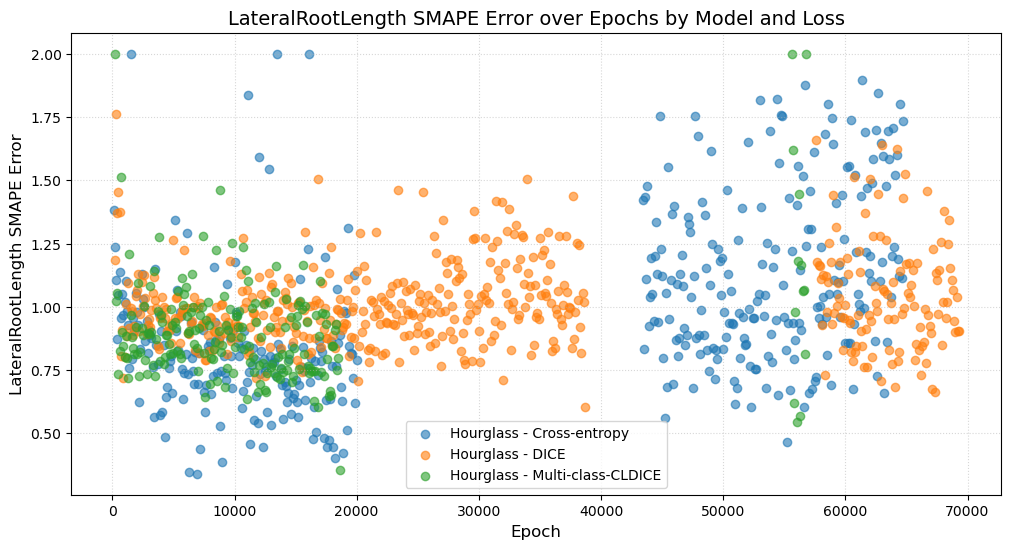

In [28]:
# scatter plot, distribution of smape error for NumberOfOrgans over the epochs

import matplotlib.pyplot as plt
metric = 'LateralRootLength'
smape_col = f"{metric}_smape_err"
plt.figure(figsize=(12, 6))
mean_smape = df_diff_log.groupby(['model', 'loss', 'epoch'])[smape_col].median().reset_index()
for (model, loss), group in mean_smape.groupby(['model', 'loss']):
    plt.scatter(group['epoch'], group[smape_col], label=f"{model} - {loss}", alpha=0.6)
plt.xlabel('Epoch')
plt.ylabel(f'{metric} SMAPE Error')
plt.title(f'{metric} SMAPE Error over Epochs by Model and Loss')
plt.legend()
plt.show()

In [29]:
# print col names
for col in df_diff_log.columns:
    print(col)

model
loss
epoch
box
time
time_hours
root_ids
Convex_Area_Hull_signed_err
Convex_Area_Hull_abs_err
Convex_Area_Hull_rel_err
Convex_Area_Hull_smape_err
LateralRootLength_signed_err
LateralRootLength_abs_err
LateralRootLength_rel_err
LateralRootLength_smape_err
NumberOfLateralRoots_signed_err
NumberOfLateralRoots_abs_err
NumberOfLateralRoots_rel_err
NumberOfLateralRoots_smape_err
NumberOfOrgans_signed_err
NumberOfOrgans_abs_err
NumberOfOrgans_rel_err
NumberOfOrgans_smape_err
PrimaryRootLength_signed_err
PrimaryRootLength_abs_err
PrimaryRootLength_rel_err
PrimaryRootLength_smape_err
RootDensity_signed_err
RootDensity_abs_err
RootDensity_rel_err
RootDensity_smape_err
TotalRootLength_signed_err
TotalRootLength_abs_err
TotalRootLength_rel_err
TotalRootLength_smape_err
Convex_Area_Hull_speed_signed_err
Convex_Area_Hull_speed_abs_err
Convex_Area_Hull_speed_rel_err
Convex_Area_Hull_speed_smape_err
Convex_Area_Hull_acceleration_signed_err
Convex_Area_Hull_acceleration_abs_err
Convex_Area_Hull_ac

In [30]:
# ignore all values after epoch 20 000 
df_diff_log = df_diff_log[df_diff_log['epoch'] <= 20000].copy()

/tmp/ipykernel_99427/1012027133.py:15: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x) + c
/tmp/ipykernel_99427/1012027133.py:15: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x) + c


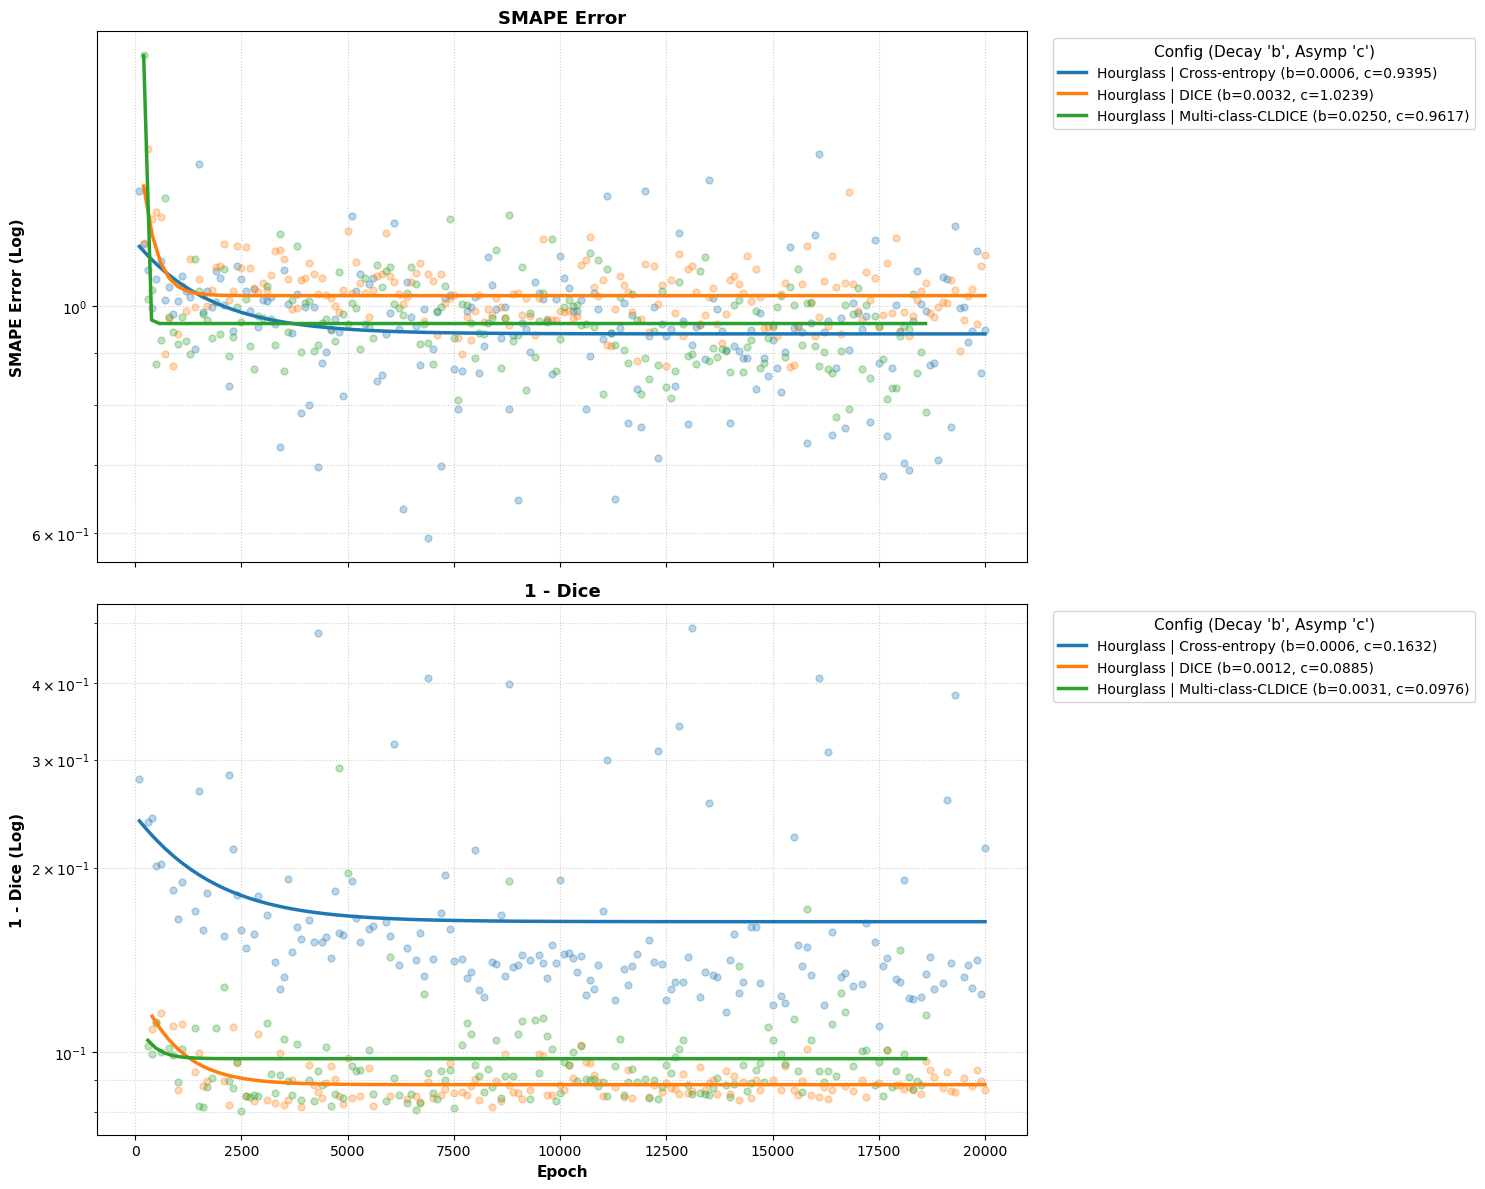

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.optimize import curve_fit

# --- Configuration ---
metric_name = 'LateralRootLength'
metrics_to_plot = {
    'SMAPE Error': f"{metric_name}_smape_err",
    '1 - Dice': "Val_Binary/Dice" # On renomme le label pour être clair
}

def model_func(x, a, b, c):
    return a * np.exp(-b * x) + c

fig, axes = plt.subplots(2, 1, figsize=(15, 12), sharex=True)

configs = df_diff_log[['model', 'loss']].drop_duplicates().reset_index(drop=True)
palette = sns.color_palette("tab10", len(configs))

for i, (label, col_name) in enumerate(metrics_to_plot.items()):
    ax = axes[i]
    mean_data = df_diff_log.groupby(['model', 'loss', 'epoch'])[col_name].mean().reset_index()
    
    ax.set_yscale('log') 
    
    handles = []
    legend_labels = []
    
    for idx, row in configs.iterrows():
        model_name = row['model']
        loss_name = row['loss']
        
        group = mean_data[(mean_data['model'] == model_name) & (mean_data['loss'] == loss_name)].copy()
        
        # --- L'ASTUCE EST ICI ---
        # Si c'est le Dice, on le transforme en erreur (1 - Dice)
        if 'Dice' in label:
            group[col_name] = group[col_name].dropna()
            group[col_name] = 1.0 - group[col_name]
            
            
        # On filtre strictement les valeurs <= 0 pour protéger le log et le fit
        group = group[group[col_name] > 0]
        
        if group.empty: continue
            
        x_data = group['epoch'].values
        y_data = group[col_name].values
        
        color = palette[idx % len(palette)]
        
        ax.scatter(x_data, y_data, color=color, alpha=0.3, s=25)
        
        fit_label = f"{model_name} | {loss_name}"
        
        try:
            # Plus besoin de if/else compliqué, toutes les courbes descendent maintenant !
            p0 = [y_data.max() - y_data.min(), 0.01, y_data.min()]
            popt, _ = curve_fit(model_func, x_data, y_data, p0=p0, maxfev=10000)
            
            fit_label += f" (b={popt[1]:.4f}, c={popt[2]:.4f})"
            
            x_fit = np.linspace(x_data.min(), x_data.max(), 100)
            y_fit = model_func(x_fit, *popt)
            
            line, = ax.plot(x_fit, y_fit, color=color, linewidth=2.5, linestyle='-')
            handles.append(line)
            legend_labels.append(fit_label)
            
        except Exception:
            line, = ax.plot([], [], color=color, linewidth=2.5, linestyle=':')
            handles.append(line)
            legend_labels.append(fit_label + " (Fit failed)")

    ax.set_ylabel(f'{label} (Log)', fontsize=11, fontweight='bold')
    ax.set_title(f'{label}', fontsize=13, fontweight='bold')
    ax.grid(True, which="both", ls=":", alpha=0.6)
    
    ax.legend(handles, legend_labels, bbox_to_anchor=(1.02, 1), loc='upper left', 
              fontsize=10, title="Config (Decay 'b', Asymp 'c')", title_fontsize=11)

axes[1].set_xlabel('Epoch', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

In [32]:
# %% [markdown]
# ## Consistency Analysis : Hard Roots Detection
# Vérifier si l'erreur est portée par des racines spécifiques (alignées sur le même axe Y) au fil des epochs.

# %%
import ipywidgets as widgets
from IPython.display import display
import seaborn as sns
import matplotlib.pyplot as plt
import ast

# On récupère toutes les métriques d'erreur disponibles
error_metrics = [col for col in df_diff_log.columns if any(x in col for x in ['_smape_err', '_abs_err', '_rel_err', '_ratio'])]

# Fonction utilitaire pour extraire l'indice y d'un tuple (x, y)
def extract_y_index(root_id):
    if isinstance(root_id, str):
        try:
            # Si c'est une string "(x, y)", on l'évalue en tuple
            parsed = ast.literal_eval(root_id)
            return parsed[1]
        except:
            return root_id # fallback
    elif isinstance(root_id, (tuple, list)) and len(root_id) >= 2:
        return root_id[1] # On prend l'indice y
    return root_id

In [33]:
def plot_root_consistency(model_name, loss_name, box_name, metric):
    # 1. Filtrer les données
    df_sub = df_diff_log[
        (df_diff_log['model'] == model_name) &
        (df_diff_log['loss'] == loss_name) &
        (df_diff_log['box'] == box_name)
    ].copy()
    
    if df_sub.empty:
        plt.figure(figsize=(14, 6))
        plt.text(0.5, 0.5, "Aucune donnée pour cette sélection", ha='center', va='center', fontsize=14)
        plt.axis('off')
        plt.show()
        return
        
    # Extraction de l'indice Z
    df_sub['z_index'] = df_sub['root_ids'].progress_apply(extract_y_index)
        
    df_pivot = df_sub.pivot_table(
        index='z_index', 
        columns='epoch', 
        values=metric, 
        aggfunc='mean'
    )
    
    # On trie l'index pour que l'axe Y de la heatmap suive un ordre logique (physique)
    df_pivot = df_pivot.sort_index()
    
    # 3. Création de la figure
    fig, axes = plt.subplots(1, 2, figsize=(20, 8), gridspec_kw={'width_ratios': [1, 1.2]})
    
    # --- GRAPH 1 : HEATMAP ---
    sns.heatmap(df_pivot, cmap='Reds', ax=axes[0], cbar_kws={'label': metric}, 
                linewidths=0.5, linecolor='lightgray')
    axes[0].set_title(f"Heatmap de l'erreur par ligne Y\n(Lignes sombres = échecs consistants)", fontsize=14)
    axes[0].set_ylabel("Root Y-Index", fontsize=12)
    axes[0].set_xlabel("Epoch", fontsize=12)
    
    # --- GRAPH 2 : SPAGHETTI PLOT ---
    # Calcul du quantile 80% sur la dernière epoch valide pour mettre en surbrillance
    last_epoch_vals = df_pivot.iloc[:, -1].dropna()
    threshold = last_epoch_vals.quantile(0.80) if not last_epoch_vals.empty else 0
    
    for y_idx in df_pivot.index:
        row_data = df_pivot.loc[y_idx].dropna()
        final_err = row_data.iloc[-1] if not row_data.empty else 0
        is_high_error = final_err > threshold
        
        alpha_val = 0.9 if is_high_error else 0.3
        linewidth = 2.5 if is_high_error else 1.0
        color = 'darkred' if is_high_error else 'gray'
        
        axes[1].plot(df_pivot.columns, df_pivot.loc[y_idx], 
                     marker='.', alpha=alpha_val, linewidth=linewidth, color=color)
        
    axes[1].set_title(f"Trajectoire de l'erreur par ligne Y\n(Rouge = Top 20% des pires lignes à la fin)", fontsize=14)
    axes[1].set_xlabel("Epoch", fontsize=12)
    # Remplacement sécurisé si renaming_dict n'est pas défini dans le scope global
    ylabel_str = metric
    axes[1].set_ylabel(ylabel_str, fontsize=12)
    axes[1].grid(True, linestyle=':', alpha=0.6)
    
    fig.suptitle(f"{model_name} | {loss_name} | Box {box_name}", fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# 4. Création des Widgets
w_mod = widgets.Dropdown(options=sorted(df_diff_log['model'].unique()), description='Model:')
w_ls = widgets.Dropdown(options=sorted(df_diff_log['loss'].unique()), description='Loss:')
w_bx = widgets.Dropdown(options=sorted(df_diff_log['box'].unique()), description='Box:')
w_met = widgets.Dropdown(options=sorted(error_metrics), description='Metric:')

ui_cons = widgets.VBox([
    widgets.HBox([w_mod, w_ls, w_bx]), 
    w_met
])

out_cons = widgets.interactive_output(plot_root_consistency, {
    'model_name': w_mod, 
    'loss_name': w_ls, 
    'box_name': w_bx, 
    'metric': w_met
})

display(ui_cons, out_cons)

Output()

In [34]:
import ipywidgets as widgets
from IPython.display import display
import seaborn as sns
import matplotlib.pyplot as plt
import ast

error_metrics = [col for col in df_diff_log.columns if any(x in col for x in ['_smape_err', '_abs_err', '_rel_err', '_ratio'])]


def plot_global_root_consistency(box_name, metric):
    df_sub = df_diff_log[df_diff_log['box'] == box_name].copy()
    
    if df_sub.empty:
        plt.figure(figsize=(14, 6))
        plt.text(0.5, 0.5, "Aucune donnée pour cette sélection", ha='center', va='center', fontsize=14)
        plt.axis('off')
        plt.show()
        return
        
    df_sub['z_index'] = df_sub['root_ids'].progress_apply(extract_y_index)
        
    df_pivot = df_sub.pivot_table(
        index='z_index', 
        columns='epoch', 
        values=metric, 
        aggfunc='mean'
    )
    
    df_pivot = df_pivot.sort_index()
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 8), gridspec_kw={'width_ratios': [1, 1.2]})

    sns.heatmap(df_pivot, cmap='Reds', ax=axes[0], cbar_kws={'label': f'Mean {metric}'}, 
                linewidths=0.5, linecolor='lightgray')
    axes[0].set_title(f"Heatmap de l'erreur MOYENNE par ligne Z\n(Tous modèles confondus)", fontsize=14)
    axes[0].set_ylabel("Root index (GT)", fontsize=12)
    axes[0].set_xlabel("Epoch", fontsize=12)
    
    last_epoch_vals = df_pivot.iloc[:, -1].dropna()
    threshold = last_epoch_vals.quantile(0.80) if not last_epoch_vals.empty else 0
    
    for z_idx in df_pivot.index:
        row_data = df_pivot.loc[z_idx].dropna()
        final_err = row_data.iloc[-1] if not row_data.empty else 0
        is_high_error = final_err > threshold
        
        alpha_val = 0.9 if is_high_error else 0.3
        linewidth = 2.5 if is_high_error else 1.0
        color = 'darkred' if is_high_error else 'gray'
        
        axes[1].plot(df_pivot.columns, df_pivot.loc[z_idx], 
                     marker='.', alpha=alpha_val, linewidth=linewidth, color=color)
        
    axes[1].set_title(f"Trajectoire Moyenne de l'erreur par ligne Z\n(Rouge = Top 20% des pires lignes à la fin)", fontsize=14)
    axes[1].set_xlabel("Epoch", fontsize=12)
    
    ylabel_str = metric
    axes[1].set_ylabel(ylabel_str, fontsize=12)
    axes[1].grid(True, linestyle=':', alpha=0.6)
    
    fig.suptitle(f"Agrégation Globale (Tous Modèles & Losses) | Box {box_name}", fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# 4. Création des Widgets (allégés)
w_bx = widgets.Dropdown(options=sorted(df_diff_log['box'].unique()), description='Box:')
w_met = widgets.Dropdown(options=sorted(error_metrics), description='Metric:')

ui_cons = widgets.HBox([w_bx, w_met])

out_cons = widgets.interactive_output(plot_global_root_consistency, {
    'box_name': w_bx, 
    'metric': w_met
})

display(ui_cons, out_cons)

Output()

In [35]:
# # scatter plot, distribution of smape error for NumberOfOrgans over the epochs

# import matplotlib.pyplot as plt
# metric = 'NumberOfLateralRoots'
# smape_col = f"{metric}_smape_err"
# plt.figure(figsize=(12, 6))
# for (model, loss), group in df_diff_log.groupby(['model', 'loss']):
#     plt.scatter(group['epoch'], group[smape_col], label=f"{model} - {loss}", alpha=0.6)
# plt.xlabel('Epoch')
# plt.ylabel(f'{metric} SMAPE Error')
# plt.title(f'{metric} SMAPE Error over Epochs by Model and Loss')
# plt.legend()
# plt.show()

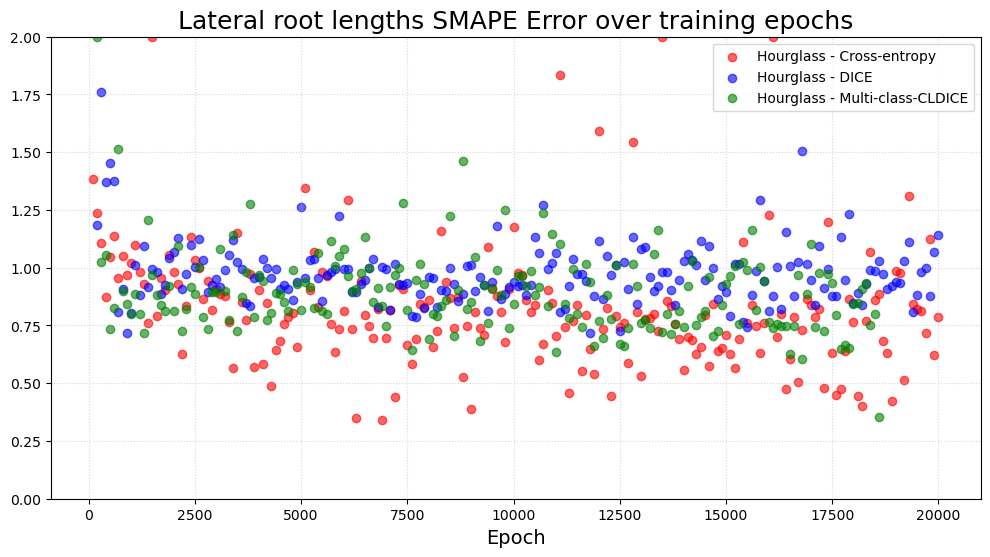

In [36]:
# scatter plot, distribution of smape error for NumberOfOrgans over the epochs

import matplotlib.pyplot as plt
metric = 'LateralRootLength'
smape_col = f"{metric}_smape_err"

# Define color mapping for losses
loss_colors = {
    'cross-entropy': 'red',
    'dice': 'blue',
    'multi-class-cldice': 'green'
}

plt.figure(figsize=(12, 6))
mean_smape = df_diff_log.groupby(['model', 'loss', 'epoch'])[smape_col].median().reset_index()
for (model, loss), group in mean_smape.groupby(['model', 'loss']):
    color = loss_colors.get(loss.lower(), 'gray')
    plt.scatter(group['epoch'], group[smape_col], label=f"{model} - {loss}", alpha=0.6, color=color)
plt.ylim(0, 2)
plt.xlabel('Epoch', fontsize=14)
plt.title(f'Lateral root lengths SMAPE Error over training epochs', fontsize=18)
plt.legend()
plt.savefig(f'{metric}_smape_error_over_epochs.png', dpi=1200, transparent=True)
plt.show()


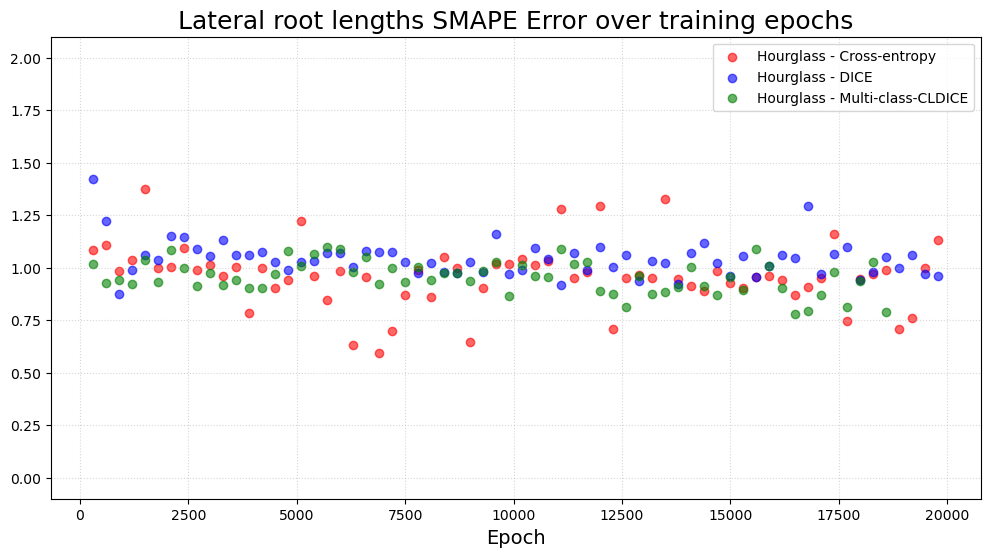

In [37]:
# scatter plot, distribution of smape error for NumberOfOrgans over the epochs

import matplotlib.pyplot as plt
metric = 'LateralRootLength'
smape_col = f"{metric}_smape_err"

# Define color mapping for losses
loss_colors = {
    'cross-entropy': 'red',
    'dice': 'blue',
    'multi-class-cldice': 'green'
}

plt.figure(figsize=(12, 6))
mean_smape = df_diff_log.groupby(['model', 'loss', 'epoch'])[smape_col].mean().reset_index()
# if epoch % 5 =! 0, drop the row
mean_smape = mean_smape[mean_smape['epoch'] % 300 == 0]
for (model, loss), group in mean_smape.groupby(['model', 'loss']):
    color = loss_colors.get(loss.lower(), 'gray')
    plt.scatter(group['epoch'], group[smape_col], label=f"{model} - {loss}", alpha=0.6, color=color)
plt.ylim(-0.1,2.1)
plt.xlabel('Epoch', fontsize=14)
plt.title(f'Lateral root lengths SMAPE Error over training epochs', fontsize=18)
plt.legend()
plt.savefig(f'{metric}_smape_error_over_epochs.png', dpi=1200, transparent=True)
plt.show()


In [38]:
print(f'col names that starts with loss/: {[col for col in df_diff_log.columns if col.startswith("loss")]}')

# create a col named val/val_loss: 
## if loss_name = "Cross-entropy" then val_loss = 'loss/val_loss_seg_ce'
## if loss_name = "DICE" then val_loss = 'loss/val_loss_seg_dice'
## if loss_name = "Multi-class-CLDICE" then val_loss = 'loss/val_loss_seg_cldice'
def map_val_loss(row):
    if row['loss'] == "Cross-entropy":
        return row.get('loss/val_loss_seg_ce', None)
    elif row['loss'] == "DICE":
        return row.get('loss/val_loss_seg_dice', None)
    elif row['loss'] == "Multi-class-CLDICE":
        return row.get('loss/val_loss_seg_cldice', None)
    return None
df_diff_log['val/val_loss'] = df_diff_log.parallel_apply(map_val_loss, axis=1)



col names that starts with loss/: ['loss']


In [39]:
df_diff_log.head()

,model,loss,epoch,box,time,time_hours,root_ids,Convex_Area_Hull_signed_err,Convex_Area_Hull_abs_err,Convex_Area_Hull_rel_err,...,Val_Loss/CLDice,Val_Binary/Recall,Val_Multi-Class/class_5_iou,Val_Binary/Normalized_Mutual_Info,Val_Binary/Hausdorff95,_runtime,Val_Multi-Class/class_2_iou,Train/Loss_Seg_dice,Train/Loss_Seg_cldice_dice,val/val_loss
28,Hourglass,Cross-entropy,100,230629PN006,0,182.6007,"(1, 31)",-1.075507,1.075507,1.0,...,0.699518,0.986672,0.222086,0.566333,0.75011,178.132865,0.382081,NaN,NaN,None
29,Hourglass,Cross-entropy,100,230629PN006,0,182.6007,"(3, 23)",-0.562321,0.562321,1.0,...,0.699518,0.986672,0.222086,0.566333,0.75011,178.132865,0.382081,NaN,NaN,None
39,Hourglass,Cross-entropy,100,230629PN006,0,182.6007,"(5, 9)",-0.444474,0.444474,1.0,...,0.699518,0.986672,0.222086,0.566333,0.75011,178.132865,0.382081,NaN,NaN,None
45,Hourglass,Cross-entropy,100,230629PN006,0,182.6007,"(7, 1)",-1.753935,1.753935,1.0,...,0.699518,0.986672,0.222086,0.566333,0.75011,178.132865,0.382081,NaN,NaN,None
67,Hourglass,Cross-entropy,100,230629PN006,0,182.6007,"(11, 21)",-1.396679,1.396679,1.0,...,0.699518,0.986672,0.222086,0.566333,0.75011,178.132865,0.382081,NaN,NaN,None


In [40]:
# print col names of df_diff_log
for col in df_diff_log.columns:
    print(col)

model
loss
epoch
box
time
time_hours
root_ids
Convex_Area_Hull_signed_err
Convex_Area_Hull_abs_err
Convex_Area_Hull_rel_err
Convex_Area_Hull_smape_err
LateralRootLength_signed_err
LateralRootLength_abs_err
LateralRootLength_rel_err
LateralRootLength_smape_err
NumberOfLateralRoots_signed_err
NumberOfLateralRoots_abs_err
NumberOfLateralRoots_rel_err
NumberOfLateralRoots_smape_err
NumberOfOrgans_signed_err
NumberOfOrgans_abs_err
NumberOfOrgans_rel_err
NumberOfOrgans_smape_err
PrimaryRootLength_signed_err
PrimaryRootLength_abs_err
PrimaryRootLength_rel_err
PrimaryRootLength_smape_err
RootDensity_signed_err
RootDensity_abs_err
RootDensity_rel_err
RootDensity_smape_err
TotalRootLength_signed_err
TotalRootLength_abs_err
TotalRootLength_rel_err
TotalRootLength_smape_err
Convex_Area_Hull_speed_signed_err
Convex_Area_Hull_speed_abs_err
Convex_Area_Hull_speed_rel_err
Convex_Area_Hull_speed_smape_err
Convex_Area_Hull_acceleration_signed_err
Convex_Area_Hull_acceleration_abs_err
Convex_Area_Hull_ac

In [41]:
# renaming columns in df_diff_log 
rename_dict = {
    # plant
    "box_name": "box",
    "plant_num": "root_ids",
    "Time elapsed (hours)": "time_hours",
    "MainRootLength_signed_err": "PrimaryRootLength_signed_err",
    "MainRootLength_abs_err": "PrimaryRootLength_abs_err",
    "MainRootLength_rel_err": "PrimaryRootLength_rel_err",
    "MainRootLength_smape_err": "PrimaryRootLength_smape_err",
    "LateralRootsLength_signed_err": "LateralRootLength_signed_err",
    "LateralRootsLength_abs_err": "LateralRootLength_abs_err",
    "LateralRootsLength_rel_err": "LateralRootLength_rel_err",
    "LateralRootsLength_smape_err": "LateralRootLength_smape_err",
    "NumberOfLateralRoots_signed_err": "NumberOfLateralRoots_signed_err",
    "NumberOfLateralRoots_abs_err": "NumberOfLateralRoots_abs_err",
    "NumberOfLateralRoots_rel_err": "NumberOfLateralRoots_rel_err",
    "NumberOfLateralRoots_smape_err": "NumberOfLateralRoots_smape_err",
    "TotalLength_signed_err": "TotalRootLength_signed_err",
    "TotalLength_abs_err": "TotalRootLength_abs_err",
    "TotalLength_rel_err": "TotalRootLength_rel_err",
    "TotalLength_smape_err": "TotalRootLength_smape_err",
    "TotalOrganCount_signed_err": "NumberOfOrgans_signed_err",
    "TotalOrganCount_abs_err": "NumberOfOrgans_abs_err",
    "TotalOrganCount_rel_err": "NumberOfOrgans_rel_err",
    "TotalOrganCount_smape_err": "NumberOfOrgans_smape_err",
    "ConvexHullArea_signed_err": "Convex_Area_Hull_signed_err",
    "ConvexHullArea_abs_err": "Convex_Area_Hull_abs_err",
    "ConvexHullArea_rel_err": "Convex_Area_Hull_rel_err",
    "ConvexHullArea_smape_err": "Convex_Area_Hull_smape_err",
    "RootDensity_signed_err": "RootDensity_signed_err",
    "RootDensity_abs_err": "RootDensity_abs_err",
    "RootDensity_rel_err": "RootDensity_rel_err",
    "RootDensity_smape_err": "RootDensity_smape_err",
    "mainRootGrad_signed_err": "PrimaryRootLength_speed_signed_err",
    "mainRootGrad_abs_err": "PrimaryRootLength_speed_abs_err",
    "mainRootGrad_rel_err": "PrimaryRootLength_speed_rel_err",
    "mainRootGrad_smape_err": "PrimaryRootLength_speed_smape_err",
    "lateralRootsGrad_signed_err": "LateralRootLength_speed_signed_err",
    "lateralRootsGrad_abs_err": "LateralRootLength_speed_abs_err",
    "lateralRootsGrad_rel_err": "LateralRootLength_speed_rel_err",
    "lateralRootsGrad_smape_err": "LateralRootLength_speed_smape_err",
    "totalRootsGrad_signed_err": "TotalRootLength_speed_signed_err",
    "totalRootsGrad_abs_err": "TotalRootLength_speed_abs_err",
    "totalRootsGrad_rel_err": "TotalRootLength_speed_rel_err",
    "totalRootsGrad_smape_err": "TotalRootLength_speed_smape_err",
    "mainRootAccel_signed_err": "PrimaryRootLength_acceleration_signed_err",
    "mainRootAccel_abs_err": "PrimaryRootLength_acceleration_abs_err",
    "mainRootAccel_rel_err": "PrimaryRootLength_acceleration_rel_err",
    "mainRootAccel_smape_err": "PrimaryRootLength_acceleration_smape_err",
    "lateralRootsAccel_signed_err": "LateralRootLength_acceleration_signed_err",
    "lateralRootsAccel_abs_err": "LateralRootLength_acceleration_abs_err",
    "lateralRootsAccel_rel_err": "LateralRootLength_acceleration_rel_err",
    "lateralRootsAccel_smape_err": "LateralRootLength_acceleration_smape_err",
    "totalRootsAccel_signed_err": "TotalRootLength_acceleration_signed_err",
    "totalRootsAccel_abs_err": "TotalRootLength_acceleration_abs_err",
    "totalRootsAccel_rel_err": "TotalRootLength_acceleration_rel_err",
    "totalRootsAccel_smape_err": "TotalRootLength_acceleration_smape_err",
    
    #img
    "val_Binary/Hausdorff": "val/HausdorffDistance",
    "val_Binary/Hausdorff_95": "val/HausdorffDistance95",
    "val_Binary/IoU": "val/IoU",
    "val_Binary/MeanIoU": "val/MeanIoU",
    "val_Binary/Precision": "val/Precision",
    "val_Binary/Recall": "val/Recall",
    "val_Binary/CL_Dice": "val/CLDice",
    "val_Binary/F2_Score": "val/F2Score",
    "val_Binary/F3_Score": "val/F3Score",
    "val_Binary/F4_Score": "val/F4Score",
    "val_Binary/dice": "val/Dice",
    "val_Binary/betti0_variation_index": "val/Betti0VariationIndexGPU",
    "val_Binary/betti1_variation_index": "val/Betti1VariationIndexGPU",
    "val_Binary/ASCD": "val/AverageSymetricCenterlineDistance",
}

df_diff_log_2_save = df_diff_log.copy().rename(columns=rename_dict)
# drop all columns that are not in rename_dict.values() and not in ['model', 'loss', 'box_name', 'img_num', 'plant_num', 'epoch', 'Time elapsed (hours)', 'Acquisition Time']
cols_to_keep = set(rename_dict.values()).union(set(['model', 'loss', 'box_name', 'img_num', 'plant_num', 'epoch', 'Time elapsed (hours)', 'Acquisition Time']))
df_diff_log_2_save = df_diff_log_2_save[[col for col in df_diff_log_2_save.columns if col in cols_to_keep]]
# print col names of df_diff_log
for col in df_diff_log_2_save.columns:
    print(col)

model
loss
epoch
box
time_hours
root_ids
Convex_Area_Hull_signed_err
Convex_Area_Hull_abs_err
Convex_Area_Hull_rel_err
Convex_Area_Hull_smape_err
LateralRootLength_signed_err
LateralRootLength_abs_err
LateralRootLength_rel_err
LateralRootLength_smape_err
NumberOfLateralRoots_signed_err
NumberOfLateralRoots_abs_err
NumberOfLateralRoots_rel_err
NumberOfLateralRoots_smape_err
NumberOfOrgans_signed_err
NumberOfOrgans_abs_err
NumberOfOrgans_rel_err
NumberOfOrgans_smape_err
PrimaryRootLength_signed_err
PrimaryRootLength_abs_err
PrimaryRootLength_rel_err
PrimaryRootLength_smape_err
RootDensity_signed_err
RootDensity_abs_err
RootDensity_rel_err
RootDensity_smape_err
TotalRootLength_signed_err
TotalRootLength_abs_err
TotalRootLength_rel_err
TotalRootLength_smape_err
LateralRootLength_speed_signed_err
LateralRootLength_speed_abs_err
LateralRootLength_speed_rel_err
LateralRootLength_speed_smape_err
LateralRootLength_acceleration_signed_err
LateralRootLength_acceleration_abs_err
LateralRootLength_

In [42]:
# save df_diff_log to csv
#df_diff_log_2_save.to_csv("RootNav2_df_diff_log.csv", index=False)

## Visualize raw data

### Utils

In [43]:
import ipywidgets as widgets
from IPython.display import display

In [44]:
# List all loss names, model names, and metrics
loss_names = df_diff_log['loss'].unique().tolist()
model_names = df_diff_log['model'].unique().tolist()
col_box_name = df_diff_log["box"].unique().tolist()
col_plant_number = df_diff_log["root_ids"].unique().tolist()
col_time_hours = df_diff_log['time'].unique().tolist()
col_time_hours.sort()
col_epoch = df_diff_log["epoch"].unique().tolist()
col_epoch.sort()
img_metrics = [col for col in df_diff_log.columns if col.startswith('val')]
img_metrics.sort()
plant_errors = [col for col in df_diff_log.columns if col not in ['model', 'loss', 'epoch', 'box', 'time', 'time_hours', 'root_ids'] and not col.startswith('val/')]
# remove everything that is not a measure
for col in ['epoch', 'loss', 'model', 'box',  'root_ids', 'TimeStep', 'FileName', 'time', 'Acquisition Time'] + img_metrics:
    if col in plant_errors:
        plant_errors.remove(col)
plant_errors.sort()
print("Available loss names:", loss_names)
print("Available model names:", model_names)
print("Available box names:", col_box_name)
print("Available plant numbers:", col_plant_number)
print("Available epochs:", col_epoch)
print("Available image metrics:", img_metrics)
print("Available plant errors:", plant_errors)


Available loss names: ['Cross-entropy', 'DICE', 'Multi-class-CLDICE']
Available model names: ['Hourglass']
Available box names: ['230629PN006', '230629PN008', '230629PN010', '230629PN012', '230629PN014', '230629PN018', '230629PN019', '230629PN024', '230629PN027', '230629PN031']
Available plant numbers: [(1, 31), (3, 23), (5, 9), (7, 1), (11, 21), (1, 23), (3, 31), (5, 21), (8, 1), (11, 9), (6, 9), (8, 21), (13, 1), (4, 31), (15, 9), (4, 1), (10, 21), (13, 31), (9, 21), (12, 9), (6, 31), (13, 9), (9, 1), (14, 21), (17, 9), (7, 31), (23, 1), (4, 9), (12, 1), (16, 21), (19, 31), (1, 21), (4, 23), (14, 9), (1, 1), (10, 23), (15, 31), (21, 9), (32, 21), (8, 23), (15, 21), (19, 9), (26, 31), (8, 31), (20, 21), (26, 9), (34, 1), (16, 9), (29, 31), (36, 1), (20, 9), (38, 21), (45, 31), (18, 21), (25, 31), (32, 9), (14, 31), (19, 21), (42, 1), (12, 31), (18, 9), (30, 1), (41, 21), (20, 1), (31, 31), (38, 9), (25, 9), (43, 21), (51, 31), (21, 31), (47, 1), (17, 21), (22, 31), (29, 9), (22, 21), 

### Visu

In [45]:
df_diff_log.head()

,model,loss,epoch,box,time,time_hours,root_ids,Convex_Area_Hull_signed_err,Convex_Area_Hull_abs_err,Convex_Area_Hull_rel_err,...,Val_Loss/CLDice,Val_Binary/Recall,Val_Multi-Class/class_5_iou,Val_Binary/Normalized_Mutual_Info,Val_Binary/Hausdorff95,_runtime,Val_Multi-Class/class_2_iou,Train/Loss_Seg_dice,Train/Loss_Seg_cldice_dice,val/val_loss
28,Hourglass,Cross-entropy,100,230629PN006,0,182.6007,"(1, 31)",-1.075507,1.075507,1.0,...,0.699518,0.986672,0.222086,0.566333,0.75011,178.132865,0.382081,NaN,NaN,None
29,Hourglass,Cross-entropy,100,230629PN006,0,182.6007,"(3, 23)",-0.562321,0.562321,1.0,...,0.699518,0.986672,0.222086,0.566333,0.75011,178.132865,0.382081,NaN,NaN,None
39,Hourglass,Cross-entropy,100,230629PN006,0,182.6007,"(5, 9)",-0.444474,0.444474,1.0,...,0.699518,0.986672,0.222086,0.566333,0.75011,178.132865,0.382081,NaN,NaN,None
45,Hourglass,Cross-entropy,100,230629PN006,0,182.6007,"(7, 1)",-1.753935,1.753935,1.0,...,0.699518,0.986672,0.222086,0.566333,0.75011,178.132865,0.382081,NaN,NaN,None
67,Hourglass,Cross-entropy,100,230629PN006,0,182.6007,"(11, 21)",-1.396679,1.396679,1.0,...,0.699518,0.986672,0.222086,0.566333,0.75011,178.132865,0.382081,NaN,NaN,None


In [46]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt

# --- 1. Define Widgets ---

w_model = widgets.Dropdown(
    options=sorted(df_diff_log['model'].unique()), 
    description='Model:'
)

w_loss = widgets.Dropdown(
    options=sorted(df_diff_log['loss'].unique()), 
    description='Loss:'
)

w_box = widgets.Dropdown(
    options=sorted(df_diff_log['box'].unique()), 
    description='Box:'
)

# Initialize with a placeholder to prevent "nonempty" error on startup
w_epoch = widgets.SelectionSlider(
    options=['N/A'], 
    description='Epoch:',
    continuous_update=False,
    disabled=True 
)

w_root_id = widgets.Dropdown(
    options=[], 
    description='Root ID:'
)

w_measure = widgets.Dropdown(
    options=plant_errors, 
    description='Measure:'
)

def update_dependent_options(*_):
    curr_model = w_model.value
    curr_loss = w_loss.value
    curr_box = w_box.value
    
    # Filter data
    subset = df_diff_log[
        (df_diff_log['model'] == curr_model) & 
        (df_diff_log['loss'] == curr_loss) & 
        (df_diff_log['box'] == curr_box)
    ]
    
    # --- Update Epochs (Fix for TraitError) ---
    available_epochs = sorted(subset['epoch'].unique())
    
    if len(available_epochs) > 0:
        w_epoch.options = available_epochs
        w_epoch.disabled = False
        # Preserve selection if valid
        if w_epoch.value not in available_epochs:
            w_epoch.value = available_epochs[-1]
    else:
        # Fallback if no data: set a dummy option
        w_epoch.options = ['N/A'] 
        w_epoch.disabled = True

    available_roots = sorted(subset['root_ids'].unique())
    print(f"Available roots for model={curr_model}, loss={curr_loss}, box={curr_box}: {available_roots}")
    
    if len(available_roots) > 0:
        w_root_id.options = available_roots
        w_root_id.disabled = False
    else:
        w_root_id.options = ['N/A']
        w_root_id.disabled = True

w_model.observe(update_dependent_options, names='value')
w_loss.observe(update_dependent_options, names='value')
w_box.observe(update_dependent_options, names='value')

update_dependent_options()

def plot_logic(model_name, loss_name, epoch, box, root_id, measure):
    if epoch == 'N/A' or root_id == 'N/A':
        plt.figure(figsize=(14, 6))
        plt.text(0.5, 0.5, "No data available for this selection", 
                 ha='center', va='center', fontsize=14)
        plt.tight_layout()
        plt.show()
        return

    df_filtered = df_diff_log[
        (df_diff_log['model'] == model_name) &
        (df_diff_log['loss'] == loss_name) &
        (df_diff_log['epoch'] == epoch) &
        (df_diff_log['box'] == box) &
        (df_diff_log['root_ids'] == root_id)
    ]
    
    df_filtered = df_filtered.sort_values('time').copy()
    # remove rows where measure is NaN
    df_filtered = df_filtered[~df_filtered[measure].isna()]

    plt.figure(figsize=(14, 6))
    
    if df_filtered.empty:
        plt.text(0.5, 0.5, "No data found", ha='center', va='center', fontsize=14)
    else:
        plt.plot(df_filtered['time'], df_filtered[measure], 
                 marker='o', color='teal', label=measure, 
                 linewidth=2, markersize=4, alpha=0.8)
        
        plt.title(f'Analysis: {measure}\n({model_name} | {loss_name} | Epoch {epoch} | Box {box} | Root {root_id})')
        plt.xlabel('Time (hours)')
        plt.ylabel(measure)
        plt.legend()
        plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

ui = widgets.VBox([
    widgets.HBox([w_model, w_loss, w_epoch]),
    widgets.HBox([w_box, w_root_id]),
    widgets.HBox([w_measure])
])

out = widgets.interactive_output(plot_logic, {
    'model_name': w_model,
    'loss_name': w_loss,
    'epoch': w_epoch,
    'box': w_box,
    'root_id': w_root_id,
    'measure': w_measure
})

display(ui, out)

Available roots for model=Hourglass, loss=Cross-entropy, box=230629PN006: [(1, 1), (1, 9), (1, 21), (1, 23), (1, 31), (3, 1), (3, 9), (3, 21), (3, 23), (3, 31), (4, 1), (4, 9), (4, 21), (4, 23), (4, 31), (5, 1), (5, 9), (5, 21), (5, 23), (5, 31), (6, 1), (6, 9), (6, 21), (6, 23), (6, 31), (7, 1), (7, 9), (7, 21), (7, 23), (7, 31), (8, 1), (8, 9), (8, 21), (8, 23), (8, 31), (9, 1), (9, 9), (9, 21), (9, 23), (9, 31), (10, 1), (10, 9), (10, 21), (10, 23), (10, 31), (11, 1), (11, 9), (11, 21), (11, 23), (11, 31), (12, 1), (12, 9), (12, 21), (12, 23), (12, 31), (13, 1), (13, 9), (13, 21), (13, 23), (13, 31), (14, 1), (14, 9), (14, 21), (14, 23), (14, 31), (15, 1), (15, 9), (15, 21), (15, 23), (15, 31), (16, 1), (16, 9), (16, 21), (16, 23), (16, 31), (17, 1), (17, 9), (17, 21), (17, 23), (17, 31), (18, 1), (18, 9), (18, 21), (18, 23), (18, 31), (19, 1), (19, 9), (19, 21), (19, 23), (19, 31), (20, 1), (20, 9), (20, 21), (20, 23), (20, 31), (21, 1), (21, 9), (21, 21), (21, 23), (21, 31), (22, 

Output()

## Per epoch visualization

In [47]:
import pandas as pd
from IPython.display import display

target_metrics = [m for m in plant_errors if '_smape' in m]

# Remplacer -1 par l'epoch max pour chaque combinaison model x loss
last_epochs = df_diff_log.groupby(['model', 'loss'])['epoch'].max().reset_index()
last_epoch_dict = {(row['model'], row['loss']): row['epoch'] for _, row in last_epochs.iterrows()}
df_diff_log['epoch'] = df_diff_log.progress_apply(lambda row: last_epoch_dict.get((row['model'], row['loss']), row['epoch']) if row['epoch'] == -1 else row['epoch'], axis=1)

df_grouped = df_diff_log[df_diff_log['epoch'] == df_diff_log.groupby(['model', 'loss'])['epoch'].transform('max')].groupby(['model', 'loss'])[target_metrics].mean()
best_configs = []

for metric in target_metrics:
    min_val = df_grouped[metric].min()
    winners = df_grouped[df_grouped[metric] <= min_val + 1e-4]
    for (model, loss), row in winners.iterrows():
        best_configs.append({
            'Metric': metric,
            'epoch': df_diff_log.loc[(df_diff_log['model'] == model) & (df_diff_log['loss'] == loss), 'epoch'].max(),
            'Best Model': model,
            'Best Loss': loss,
            'Min Mean Error': row[metric]
        })

df_best = pd.DataFrame(best_configs)

display(df_best.style.background_gradient(subset=['Min Mean Error'], cmap='Greens_r'))

Processing renaming models: 100%|██████████| 664626/664626 [00:05<00:00, 119217.29it/s]


,Metric,epoch,Best Model,Best Loss,Min Mean Error
0,Convex_Area_Hull_acceleration_smape_err,20000,Hourglass,Cross-entropy,1.339668
1,Convex_Area_Hull_smape_err,20000,Hourglass,Cross-entropy,0.297635
2,Convex_Area_Hull_speed_smape_err,20000,Hourglass,Cross-entropy,0.797459
3,LateralRootLength_acceleration_smape_err,20000,Hourglass,DICE,1.529183
4,LateralRootLength_smape_err,18600,Hourglass,Multi-class-CLDICE,0.788742
5,LateralRootLength_speed_smape_err,18600,Hourglass,Multi-class-CLDICE,0.917137
6,NumberOfLateralRoots_acceleration_smape_err,20000,Hourglass,Cross-entropy,1.287891
7,NumberOfLateralRoots_smape_err,20000,Hourglass,Cross-entropy,0.537205
8,NumberOfLateralRoots_speed_smape_err,20000,Hourglass,Cross-entropy,0.989835
9,NumberOfOrgans_acceleration_smape_err,20000,Hourglass,DICE,1.409949


In [48]:
import pandas as pd
from IPython.display import display

target_metrics = [m for m in plant_errors if '_smape' in m]

last_epochs = df_diff_log.groupby(['model', 'loss'])['epoch'].max().reset_index()
last_epoch_dict = {(row['model'], row['loss']): row['epoch'] for _, row in last_epochs.iterrows()}
df_diff_log['epoch'] = df_diff_log.progress_apply(lambda row: last_epoch_dict.get((row['model'], row['loss']), row['epoch']) if row['epoch'] == -1 else row['epoch'], axis=1)

df_grouped = df_diff_log[df_diff_log['epoch'] == df_diff_log.groupby(['model', 'loss'])['epoch'].transform('max')].groupby(['model', 'loss'])[target_metrics].mean() # meean over all measures for each model x loss combination at last epoch
best_configs = []

for metric in target_metrics:
    max_val = df_grouped[metric].max() # .max()
    winners = df_grouped[df_grouped[metric] >= max_val - 1e-4]
    for (model, loss), row in winners.iterrows():
        best_configs.append({
            'Metric': metric,
            'epoch': df_diff_log.loc[(df_diff_log['model'] == model) & (df_diff_log['loss'] == loss), 'epoch'].max(),
            'Best Model': model,
            'Best Loss': loss,
            'Max Mean Error': row[metric]
        })

df_best = pd.DataFrame(best_configs)

display(df_best.style.background_gradient(subset=['Max Mean Error'], cmap='Reds_r'))

Processing renaming models: 100%|██████████| 664626/664626 [00:05<00:00, 122046.11it/s]


,Metric,epoch,Best Model,Best Loss,Max Mean Error
0,Convex_Area_Hull_acceleration_smape_err,20000,Hourglass,DICE,1.354176
1,Convex_Area_Hull_smape_err,20000,Hourglass,DICE,0.500706
2,Convex_Area_Hull_speed_smape_err,20000,Hourglass,DICE,0.941617
3,LateralRootLength_acceleration_smape_err,20000,Hourglass,Cross-entropy,1.637236
4,LateralRootLength_smape_err,20000,Hourglass,DICE,1.122815
5,LateralRootLength_speed_smape_err,20000,Hourglass,Cross-entropy,1.405154
6,NumberOfLateralRoots_acceleration_smape_err,20000,Hourglass,DICE,1.290701
7,NumberOfLateralRoots_smape_err,20000,Hourglass,DICE,0.737501
8,NumberOfLateralRoots_speed_smape_err,20000,Hourglass,DICE,1.066509
9,NumberOfOrgans_acceleration_smape_err,20000,Hourglass,Cross-entropy,1.423681


In [49]:
# print col name that starts with val/
for col in df_diff_log.columns:
    print(col)

model
loss
epoch
box
time
time_hours
root_ids
Convex_Area_Hull_signed_err
Convex_Area_Hull_abs_err
Convex_Area_Hull_rel_err
Convex_Area_Hull_smape_err
LateralRootLength_signed_err
LateralRootLength_abs_err
LateralRootLength_rel_err
LateralRootLength_smape_err
NumberOfLateralRoots_signed_err
NumberOfLateralRoots_abs_err
NumberOfLateralRoots_rel_err
NumberOfLateralRoots_smape_err
NumberOfOrgans_signed_err
NumberOfOrgans_abs_err
NumberOfOrgans_rel_err
NumberOfOrgans_smape_err
PrimaryRootLength_signed_err
PrimaryRootLength_abs_err
PrimaryRootLength_rel_err
PrimaryRootLength_smape_err
RootDensity_signed_err
RootDensity_abs_err
RootDensity_rel_err
RootDensity_smape_err
TotalRootLength_signed_err
TotalRootLength_abs_err
TotalRootLength_rel_err
TotalRootLength_smape_err
Convex_Area_Hull_speed_signed_err
Convex_Area_Hull_speed_abs_err
Convex_Area_Hull_speed_rel_err
Convex_Area_Hull_speed_smape_err
Convex_Area_Hull_acceleration_signed_err
Convex_Area_Hull_acceleration_abs_err
Convex_Area_Hull_ac

## Prep for tables

In [50]:
print( [col for col in df_diff_log.columns if col.startswith('Val_Binary/') and col not in loss_metrics])

['Val_Binary/Betti1_abs', 'Val_Binary/F4_Score', 'Val_Binary/Precision', 'Val_Binary/IoU', 'Val_Binary/Dice', 'Val_Binary/PixelAccuracy', 'Val_Binary/ASCD', 'Val_Binary/Betti0_var_index', 'Val_Binary/Mean_IoU', 'Val_Binary/Hausdorff', 'Val_Binary/Specificity', 'Val_Binary/Betti1_var_index', 'Val_Binary/F3_Score', 'Val_Binary/CLDice', 'Val_Binary/Betti0_abs', 'Val_Binary/F1_Score', 'Val_Binary/F2_Score', 'Val_Binary/Recall', 'Val_Binary/Normalized_Mutual_Info', 'Val_Binary/Hausdorff95']


In [51]:
from scipy.stats import spearmanr, pearsonr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



loss_metrics = ['val/val_loss']

img_metrics = ['Val_Binary/Precision', 'Val_Binary/Recall', 'Val_Binary/F1_Score', 'Val_Binary/F2_Score', 'Val_Binary/IoU', 'Val_Binary/F4_Score', 'Val_Binary/Hausdorff95', 'Val_Binary/ASCD', 'Val_Binary/Betti0_var_index', 'Val_Binary/Betti1_var_index']

scores_img_metrics = ["val_Binary/Precision", "val_Binary/Recall", "val_Binary/Dice", "val_Binary/F2_Score", "val_Binary/IoU_Binary"]
plant_abs_err =  ['NumberOfLateralRoots_abs_err', 'PrimaryRootLength_abs_err', 'LateralRootLength_abs_err', 'TotalRootLength_abs_err', 'PrimaryRootLength_speed_abs_err', 'PrimaryRootLength_acceleration_abs_err','LateralRootLength_speed_abs_err', 'LateralRootLength_acceleration_abs_err', 'RootDensity_abs_err', 'Convex_Area_Hull_abs_err'] # 'NumberOfOrgans_abs_err'
plant_rel_err = ['NumberOfLateralRoots_rel_err', 'PrimaryRootLength_rel_err', 'LateralRootLength_rel_err', 'TotalRootLength_rel_err', 'PrimaryRootLength_speed_rel_err', 'PrimaryRootLength_acceleration_rel_err','LateralRootLength_speed_rel_err', 'LateralRootLength_acceleration_rel_err', 'RootDensity_rel_err', 'Convex_Area_Hull_rel_err']
plant_smape_err = ['NumberOfLateralRoots_smape_err', 'PrimaryRootLength_smape_err', 'LateralRootLength_smape_err', 'TotalRootLength_smape_err', 'PrimaryRootLength_speed_smape_err', 'PrimaryRootLength_acceleration_smape_err','LateralRootLength_speed_smape_err', 'LateralRootLength_acceleration_smape_err', 'RootDensity_smape_err', 'Convex_Area_Hull_smape_err']
plant_ratio = ['NumberOfLateralRoots_ratio_err', 'PrimaryRootLength_ratio_err', 'LateralRootLength_ratio_err', 'TotalRootLength_ratio_err', 'PrimaryRootLength_speed_ratio_err', 'PrimaryRootLength_acceleration_ratio_err','LateralRootLength_speed_ratio_err', 'LateralRootLength_acceleration_ratio_err', 'RootDensity_ratio_err', 'Convex_Area_Hull_ratio_err']
plant_signed_err = [col for col in plant_errors if 'signed_err' in col]

plant_errors = plant_smape_err
renaming_dict = {
    'NumberOfLateralRoots_abs_err': 'Number of Lateral Roots Absolute Error',
    'NumberOfLateralRoots_rel_err': 'Number of Lateral Roots Relative Error',
    'NumberOfLateralRoots_smape_err': 'Number of Lateral Roots',  # SMAPE Error
    'PrimaryRootLength_smape_err': 'Primary Root Length',  # SMAPE Error
    'LateralRootLength_smape_err': 'Lateral Roots Length',  # SMAPE Error
    'TotalRootLength_smape_err': 'Total Root Length',  # SMAPE Error
    'PrimaryRootLength_speed_smape_err': 'Primary Root Length Speed',  # SMAPE Error
    'PrimaryRootLength_acceleration_smape_err': 'Primary Root Length Acceleration',  # SMAPE Error
    'LateralRootLength_speed_smape_err': 'Lateral Root Length Speed',  # SMAPE Error
    'LateralRootLength_acceleration_smape_err': 'Lateral Root Length Acceleration',  # SMAPE Error
    'RootDensity_smape_err': 'Root Density',  # SMAPE Error
    'Convex_Area_Hull_smape_err': 'Convex Area Hull',  # SMAPE Error

    'NumberOfOrgans_rel_err': 'Number of Organs Relative Error',
    'PrimaryRootLength_rel_err': 'Primary Root Length Relative Error',
    'LateralRootLength_rel_err': 'Lateral Root Length Relative Error',
    'TotalRootLength_rel_err': 'Total Root Length Relative Error',
    'PrimaryRootLength_speed_rel_err': 'Primary Root Length Speed Relative Error',
    'PrimaryRootLength_acceleration_rel_err': 'Primary Root Length Acceleration Relative Error',
    'LateralRootLength_speed_rel_err': 'Lateral Root Length Speed Relative Error',
    'LateralRootLength_acceleration_rel_err': 'Lateral Root Length Acceleration Relative Error',
    'RootDensity_rel_err': 'Root Density Relative Error',
    'Convex_Area_Hull_rel_err': 'Convex Area Hull Relative Error',
    
    'NumberOfOrgans_abs_err': 'Number of Organs Absolute Error',
    'PrimaryRootLength_abs_err': 'Primary Root Length Absolute Error',
    'LateralRootLength_abs_err': 'Lateral Root Length Absolute Error',
    'TotalRootLength_abs_err': 'Total Root Length Absolute Error',
    'PrimaryRootLength_speed_abs_err': 'Primary Root Length Speed Absolute Error',
    'PrimaryRootLength_acceleration_abs_err': 'Primary Root Length Acceleration Absolute Error',
    'LateralRootLength_speed_abs_err': 'Lateral Root Length Speed Absolute Error',
    'LateralRootLength_acceleration_abs_err': 'Lateral Root Length Acceleration Absolute Error',
    'RootDensity_abs_err': 'Root Density Absolute Error',
    'Convex_Area_Hull_abs_err': 'Convex Area Hull Absolute Error',
    
    'val_Precision': 'Precision',
    'val_Recall': 'Recall',
    'val_Dice': 'Dice Coefficient',
    'val_F2Score': 'F2 Score',
    'val_IoU': 'Intersection over Union',
    'val_HausdorffDistance95': 'Hausdorff Distance 95th Percentile',
    'val_AverageSymetricCenterlineDistance': 'Average Symmetric Centerline Distance',
    'val_Betti0VariationIndexGPU': 'Betti0 Variation Index',
    'val_Betti1VariationIndexGPU': 'Betti1 Variation Index',    
}   

### Mean SMAPE value over the epochs

In [52]:
df_diff_log.head()

,model,loss,epoch,box,time,time_hours,root_ids,Convex_Area_Hull_signed_err,Convex_Area_Hull_abs_err,Convex_Area_Hull_rel_err,...,Val_Loss/CLDice,Val_Binary/Recall,Val_Multi-Class/class_5_iou,Val_Binary/Normalized_Mutual_Info,Val_Binary/Hausdorff95,_runtime,Val_Multi-Class/class_2_iou,Train/Loss_Seg_dice,Train/Loss_Seg_cldice_dice,val/val_loss
28,Hourglass,Cross-entropy,100,230629PN006,0,182.6007,"(1, 31)",-1.075507,1.075507,1.0,...,0.699518,0.986672,0.222086,0.566333,0.75011,178.132865,0.382081,NaN,NaN,None
29,Hourglass,Cross-entropy,100,230629PN006,0,182.6007,"(3, 23)",-0.562321,0.562321,1.0,...,0.699518,0.986672,0.222086,0.566333,0.75011,178.132865,0.382081,NaN,NaN,None
39,Hourglass,Cross-entropy,100,230629PN006,0,182.6007,"(5, 9)",-0.444474,0.444474,1.0,...,0.699518,0.986672,0.222086,0.566333,0.75011,178.132865,0.382081,NaN,NaN,None
45,Hourglass,Cross-entropy,100,230629PN006,0,182.6007,"(7, 1)",-1.753935,1.753935,1.0,...,0.699518,0.986672,0.222086,0.566333,0.75011,178.132865,0.382081,NaN,NaN,None
67,Hourglass,Cross-entropy,100,230629PN006,0,182.6007,"(11, 21)",-1.396679,1.396679,1.0,...,0.699518,0.986672,0.222086,0.566333,0.75011,178.132865,0.382081,NaN,NaN,None


In [53]:
# mean value over all epochs 
df_diff_log_epoch_mean = df_diff_log.copy()

# # reverse the sign of scores metrics to have all metrics in the same direction (lower is better)
for metric in scores_img_metrics:
    if metric not in df_diff_log_epoch_mean.columns:
        # Remove metric from cols_to_keep if it does not exist in the dataframe        if metric in img_metrics:
        continue
    df_diff_log_epoch_mean[metric] = 1 - df_diff_log_epoch_mean[metric]
    df_diff_log[metric] = 1 - df_diff_log[metric]

# drop all columns that are not model, loss, epoch, img_metrics or plant_errors
cols_to_keep = ['model', 'loss', 'epoch'] + img_metrics + plant_errors + loss_metrics
df_diff_log_epoch_mean = df_diff_log_epoch_mean[cols_to_keep]

df_diff_log_epoch_mean = df_diff_log_epoch_mean.groupby(['model', 'loss', 'epoch']).mean().reset_index() # does not average segmentation metrics because for 1 model x loss x epoch = 1 segmentation value but multiple plants values
df_diff_log_epoch_mean

,model,loss,epoch,Val_Binary/Precision,Val_Binary/Recall,Val_Binary/F1_Score,Val_Binary/F2_Score,Val_Binary/IoU,Val_Binary/F4_Score,Val_Binary/Hausdorff95,...,PrimaryRootLength_smape_err,LateralRootLength_smape_err,TotalRootLength_smape_err,PrimaryRootLength_speed_smape_err,PrimaryRootLength_acceleration_smape_err,LateralRootLength_speed_smape_err,LateralRootLength_acceleration_smape_err,RootDensity_smape_err,Convex_Area_Hull_smape_err,val/val_loss
0,Hourglass,Cross-entropy,100,0.531337,0.986672,0.690592,0.842165,0.566042,0.939253,0.750110,...,0.898577,1.294571,0.386679,1.232323,1.651051,1.494974,1.785013,0.682336,0.540795,NaN
1,Hourglass,Cross-entropy,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.332869,1.150077,0.244094,0.563744,1.204098,1.352511,1.502611,0.520489,0.603106,NaN
2,Hourglass,Cross-entropy,300,0.593711,0.984720,0.740708,0.870031,0.617219,0.947959,0.197908,...,0.363258,1.085499,0.306796,0.654050,1.294199,1.383995,1.579135,0.525324,0.551129,NaN
3,Hourglass,Cross-entropy,400,0.588442,0.979048,0.734979,0.864201,0.612990,0.942210,0.259125,...,0.136274,0.995822,0.212698,0.422156,1.054265,1.384311,1.593795,0.476337,0.470422,NaN
4,Hourglass,Cross-entropy,500,0.646708,0.982211,0.779845,0.889820,0.666350,0.953099,0.125986,...,0.096213,1.063991,0.199682,0.302841,1.051194,1.400471,1.618664,0.442532,0.506374,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
578,Hourglass,Multi-class-CLDICE,18200,0.896145,0.914896,0.905421,0.911082,0.833224,0.913770,0.078702,...,0.058044,0.949002,0.196876,0.234958,1.054907,1.199180,1.475986,0.368536,0.479220,NaN
579,Hourglass,Multi-class-CLDICE,18300,0.883011,0.941813,0.911463,0.929434,0.839772,0.938138,0.079253,...,0.080034,1.028115,0.272343,0.291880,1.092631,1.411356,1.691435,0.419232,0.422625,NaN
580,Hourglass,Multi-class-CLDICE,18400,0.899415,0.913933,0.906615,0.910991,0.835348,0.913065,0.081283,...,0.053467,0.861335,0.155552,0.244490,1.033061,1.081218,1.301607,0.350159,0.455243,NaN
581,Hourglass,Multi-class-CLDICE,18500,0.884875,0.932390,0.908009,0.922482,0.837789,0.929454,0.077818,...,0.066216,0.902850,0.184586,0.288222,1.137198,1.141836,1.367568,0.360929,0.451307,NaN


### $\Delta$ and mean $\Delta$ over successive epochs

In [54]:
# mean value over all epochs 
df_diff_delta = df_diff_log.copy()

# for each model, loss, box, root_id, compute the difference between successive epochs for each metric
df_diff_delta = df_diff_delta.sort_values(by=['model', 'loss', 'box', 'root_ids', 'time', 'time_hours', 'epoch'])
for metric in img_metrics + plant_errors:
    df_diff_delta[metric] = df_diff_delta.groupby(['model', 'loss', 'box', 'root_ids', 'time', 'time_hours'])[metric].diff()
    
df_diff_delta.head()

,model,loss,epoch,box,time,time_hours,root_ids,Convex_Area_Hull_signed_err,Convex_Area_Hull_abs_err,Convex_Area_Hull_rel_err,...,Val_Loss/CLDice,Val_Binary/Recall,Val_Multi-Class/class_5_iou,Val_Binary/Normalized_Mutual_Info,Val_Binary/Hausdorff95,_runtime,Val_Multi-Class/class_2_iou,Train/Loss_Seg_dice,Train/Loss_Seg_cldice_dice,val/val_loss
97272,Hourglass,Cross-entropy,8500,230629PN006,0,182.6007,"(1, 1)",1.265741,1.265741,1.0,...,0.354226,NaN,0.417009,0.732880,NaN,9004.526073,0.649826,NaN,NaN,None
116084,Hourglass,Cross-entropy,10100,230629PN006,0,182.6007,"(1, 1)",-2.734097,2.734097,1.0,...,0.331858,0.005427,0.403603,0.734083,-0.103553,10686.883024,0.658703,NaN,NaN,None
146095,Hourglass,Cross-entropy,12700,230629PN006,0,182.6007,"(1, 1)",-1.802319,1.802319,1.0,...,0.347722,-0.005657,0.440852,0.746021,0.006528,13422.713734,0.655455,NaN,NaN,None
147280,Hourglass,Cross-entropy,12800,230629PN006,0,182.6007,"(1, 1)",-1.972062,1.972062,1.0,...,0.474554,0.013688,0.269173,0.530956,3.147374,13544.753454,0.541993,NaN,NaN,None
148225,Hourglass,Cross-entropy,12900,230629PN006,0,182.6007,"(1, 1)",-2.394677,2.394677,1.0,...,0.323922,-0.010645,0.427527,0.749355,-3.157719,13648.577001,0.650746,NaN,NaN,None


In [55]:
df_diff_mean_delta = df_diff_delta[cols_to_keep].copy().groupby(['model', 'loss', 'epoch']).mean().reset_index()
df_diff_mean_delta.head()

,model,loss,epoch,Val_Binary/Precision,Val_Binary/Recall,Val_Binary/F1_Score,Val_Binary/F2_Score,Val_Binary/IoU,Val_Binary/F4_Score,Val_Binary/Hausdorff95,...,PrimaryRootLength_smape_err,LateralRootLength_smape_err,TotalRootLength_smape_err,PrimaryRootLength_speed_smape_err,PrimaryRootLength_acceleration_smape_err,LateralRootLength_speed_smape_err,LateralRootLength_acceleration_smape_err,RootDensity_smape_err,Convex_Area_Hull_smape_err,val/val_loss
0,Hourglass,Cross-entropy,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Hourglass,Cross-entropy,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.533261,-0.238616,-0.175334,-0.958545,-0.582934,-0.134528,-0.344004,-0.121727,0.075041,NaN
2,Hourglass,Cross-entropy,300,0.062374,-0.001952,0.050116,0.027866,0.051177,0.008706,-0.552202,...,-0.181578,-0.065640,0.013659,-0.043601,-0.029927,0.026357,0.179203,-0.053344,-0.066992,NaN
3,Hourglass,Cross-entropy,400,0.014181,-0.006281,0.009898,0.002859,0.011730,-0.003034,-0.110975,...,-0.233002,-0.056320,-0.075854,-0.334965,-0.333106,-0.014563,-0.115439,-0.057292,-0.060582,NaN
4,Hourglass,Cross-entropy,500,0.065063,0.000051,0.049585,0.026928,0.058983,0.009347,-0.186075,...,-0.156735,-0.056907,-0.034319,-0.217937,-0.060065,-0.043997,0.015651,-0.071845,-0.002080,NaN


### $\Delta$ \ $\Delta_{Loss}$ and mean $\Delta$ \ $\Delta_{Loss}$ over successive epochs

In [56]:
df_diff_delta_over_loss = df_diff_log.copy()

# for each model, loss, box, root_id, compute the derivative between successive epochs for each metric with respect to the loss metric
df_diff_delta = df_diff_delta.sort_values(by=['model', 'loss', 'box', 'root_ids', 'time', 'time_hours', 'epoch'])
for metric in img_metrics + plant_errors + loss_metrics:
    df_diff_delta_over_loss[metric] = df_diff_delta.groupby(['model', 'loss', 'box', 'root_ids', 'time', 'time_hours'])[metric].diff() / df_diff_delta.groupby(['model', 'loss', 'box', 'root_ids', 'time', 'time_hours'])[loss_metrics[0]].diff()
df_diff_delta_over_loss.head()

,model,loss,epoch,box,time,time_hours,root_ids,Convex_Area_Hull_signed_err,Convex_Area_Hull_abs_err,Convex_Area_Hull_rel_err,...,Val_Loss/CLDice,Val_Binary/Recall,Val_Multi-Class/class_5_iou,Val_Binary/Normalized_Mutual_Info,Val_Binary/Hausdorff95,_runtime,Val_Multi-Class/class_2_iou,Train/Loss_Seg_dice,Train/Loss_Seg_cldice_dice,val/val_loss
28,Hourglass,Cross-entropy,100,230629PN006,0,182.6007,"(1, 31)",-1.075507,1.075507,1.0,...,0.699518,NaN,0.222086,0.566333,NaN,178.132865,0.382081,NaN,NaN,NaN
29,Hourglass,Cross-entropy,100,230629PN006,0,182.6007,"(3, 23)",-0.562321,0.562321,1.0,...,0.699518,NaN,0.222086,0.566333,NaN,178.132865,0.382081,NaN,NaN,NaN
39,Hourglass,Cross-entropy,100,230629PN006,0,182.6007,"(5, 9)",-0.444474,0.444474,1.0,...,0.699518,NaN,0.222086,0.566333,NaN,178.132865,0.382081,NaN,NaN,NaN
45,Hourglass,Cross-entropy,100,230629PN006,0,182.6007,"(7, 1)",-1.753935,1.753935,1.0,...,0.699518,NaN,0.222086,0.566333,NaN,178.132865,0.382081,NaN,NaN,NaN
67,Hourglass,Cross-entropy,100,230629PN006,0,182.6007,"(11, 21)",-1.396679,1.396679,1.0,...,0.699518,NaN,0.222086,0.566333,NaN,178.132865,0.382081,NaN,NaN,NaN


In [57]:
# assert val_loss has only nan or 1 values
unique_val_loss = df_diff_delta_over_loss[loss_metrics[0]].unique()
print("Unique values in val_loss after diff over loss:", unique_val_loss)
df_diff_delta_over_loss.dropna(subset=loss_metrics, inplace=True)

Unique values in val_loss after diff over loss: [nan]


In [58]:
df_diff_mean_delta_over_loss = df_diff_delta_over_loss[cols_to_keep].copy().groupby(['model', 'loss', 'epoch']).mean().reset_index()
df_diff_mean_delta_over_loss.head()

,model,loss,epoch,Val_Binary/Precision,Val_Binary/Recall,Val_Binary/F1_Score,Val_Binary/F2_Score,Val_Binary/IoU,Val_Binary/F4_Score,Val_Binary/Hausdorff95,...,PrimaryRootLength_smape_err,LateralRootLength_smape_err,TotalRootLength_smape_err,PrimaryRootLength_speed_smape_err,PrimaryRootLength_acceleration_smape_err,LateralRootLength_speed_smape_err,LateralRootLength_acceleration_smape_err,RootDensity_smape_err,Convex_Area_Hull_smape_err,val/val_loss


### Ebisuzaki correlation

In [59]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

def phase_scramble(series, n_surrogates=1000):
    series = np.array(series)
    n = len(series)
    

    f_series = np.fft.rfft(series)
    
    random_phases = np.random.uniform(0, 2*np.pi, (n_surrogates, len(f_series)))
    random_phases[:, 0] = 0 
    if n % 2 == 0:
        random_phases[:, -1] = 0 
        
    f_surrogates = f_series * np.exp(1j * random_phases)
    
    surrogates = np.fft.irfft(f_surrogates, n=n, axis=1)
    
    return surrogates

def ebisuzaki_correlation_test(x, y, n_surrogates=1000, metric='pearson'):
    mask = ~np.isnan(x) & ~np.isnan(y)
    x_clean, y_clean = x[mask], y[mask]
    
    if len(x_clean) < 3:
        return np.nan, np.nan

    if metric == 'pearson':
        r_obs, _ = pearsonr(x_clean, y_clean)
    elif metric == 'spearman':
        r_obs, _ = spearmanr(x_clean, y_clean)
    x_surrogates = phase_scramble(x_clean, n_surrogates)
    
    r_null = []
    for x_surr in x_surrogates:
        if metric == 'pearson':
            r, _ = pearsonr(x_surr, y_clean)
        elif metric == 'spearman':
            r, _ = spearmanr(x_surr, y_clean)
        r_null.append(r)
    
    r_null = np.array(r_null)
    p_value = np.mean(np.abs(r_null) >= np.abs(r_obs))
    
    return r_obs, p_value


## Rank table

In [60]:
import pandas as pd

df_diff_log2 = df_diff_log.copy()
last_epoch_df = df_diff_log2[df_diff_log2['epoch'] == df_diff_log2.groupby(['model', 'loss'])['epoch'].transform('max')]

target_plant_metrics = plant_smape_err
cols_to_agg = img_metrics + target_plant_metrics
df_last_agg = last_epoch_df.groupby(['model', 'loss'])[cols_to_agg].mean().reset_index()

df_ranks = pd.DataFrame()
df_ranks['config'] = df_last_agg['model'] + ' × ' + df_last_agg['loss'] 

precision = 3

for metric in img_metrics:
    rounded_series = df_last_agg[metric].round(precision)
    if metric in scores_img_metrics:
        df_ranks[metric] = rounded_series.rank(ascending=False, method='dense')
    else:
        df_ranks[metric] = rounded_series.rank(ascending=True, method='dense')
        
for metric in target_plant_metrics:
    rounded_series = df_last_agg[metric].round(precision)
    df_ranks[metric] = rounded_series.rank(ascending=True, method='dense')
    
df_ranks_plot = df_ranks.set_index('config')[cols_to_agg]
df_vals_plot = df_last_agg.copy()
df_vals_plot['config'] = df_vals_plot['model'] + ' × ' + df_vals_plot['loss']
df_vals_plot = df_vals_plot.set_index('config')[cols_to_agg]

df_ranks_plot.columns = [renaming_dict.get(col, col) for col in df_ranks_plot.columns]
df_vals_plot.columns = [renaming_dict.get(col, col) for col in df_vals_plot.columns]

def format_val(v):
    if pd.isna(v): return ""
    if abs(v) >= 100: return f"({v:.0f})"     
    elif abs(v) >= 10: return f"({v:.1f})"    
    elif abs(v) >= 1: return f"({v:.2f})"     
    else: return f"({v:.3f})"

VMAX_TARGET used for color normalization: 33.00% relative error


,Val_Binary/Precision,Val_Binary/Recall,Val_Binary/F1_Score,Val_Binary/F2_Score,Val_Binary/IoU,Val_Binary/F4_Score,Val_Binary/Hausdorff95,Val_Binary/ASCD,Val_Binary/Betti0_var_index,Val_Binary/Betti1_var_index,NumberOfLateralRoots_smape_err,PrimaryRootLength_smape_err,LateralRootLength_smape_err,TotalRootLength_smape_err,PrimaryRootLength_speed_smape_err,PrimaryRootLength_acceleration_smape_err,LateralRootLength_speed_smape_err,LateralRootLength_acceleration_smape_err,RootDensity_smape_err,Convex_Area_Hull_smape_err
config,,,,,,,,,,,,,,,,,,,,
Hourglass × Cross-entropy,0.0,0.268142,0.000000,0.000000,0.000000,0.175613,1.0,1.0,1.0,1.0,0.000000,0.406511,0.607811,1.0,1.0,0.000000,1.0,0.214124,0.273858,0.000000
Hourglass × DICE,1.0,0.047386,0.496991,0.078499,0.909192,0.048789,0.0,0.0,0.0,0.0,1.000000,1.000000,1.000000,1.0,1.0,0.344757,1.0,0.000000,1.000000,1.000000
Hourglass × Multi-class-CLDICE,1.0,0.000000,0.429375,0.025909,0.691667,0.000000,1.0,1.0,1.0,1.0,0.744582,0.000000,0.000000,0.0,0.0,NaN,0.0,NaN,0.000000,0.546441


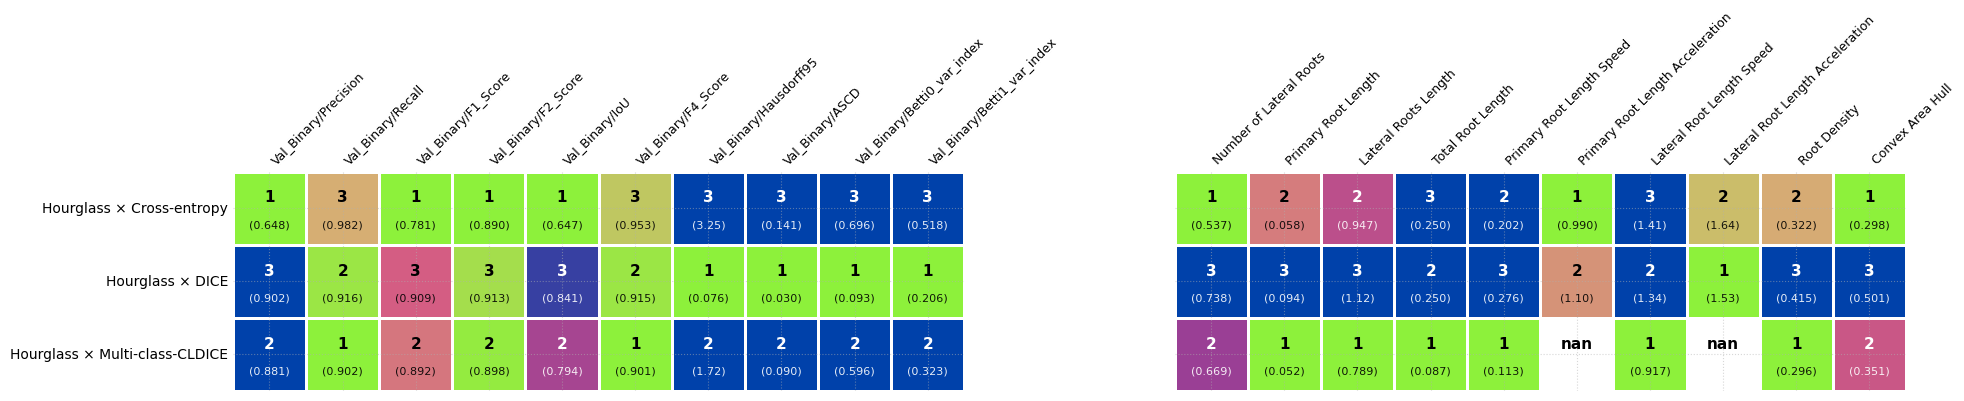

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import numpy as np

df_diff_log2 = df_diff_log.copy()
last_epoch_df = df_diff_log2[df_diff_log2['epoch'] == df_diff_log2.groupby(['model', 'loss'])['epoch'].transform('max')].copy()

target_plant_metrics = plant_smape_err
cols_to_agg = img_metrics + target_plant_metrics
df_last_agg = last_epoch_df.groupby(['model', 'loss'])[cols_to_agg].mean().reset_index()
df_last_agg['config'] = df_last_agg['model'] + ' × ' + df_last_agg['loss']

df_ranks = pd.DataFrame()
df_ranks['config'] = df_last_agg['config']

df_rel_err = pd.DataFrame(index=df_last_agg.index)

def rank_with_tolerance(series, ascending=True, tol_rel=0.00, tol_abs=0.00):
    s_clean = series.dropna().sort_values(ascending=ascending)
    ranks = pd.Series(index=series.index, dtype=int)
    if s_clean.empty: return ranks
    current_rank, base_val = 1, s_clean.iloc[0]
    for idx, val in s_clean.items():
        allowed_diff = max(tol_rel * abs(base_val), tol_abs)
        if abs(val - base_val) > allowed_diff:
            current_rank += 1
            base_val = val
        ranks.loc[idx] = current_rank
    return ranks


for metric in cols_to_agg:
    series = df_last_agg[metric]
    is_score = (metric in scores_img_metrics) if 'scores_img_metrics' in locals() else False
    
    # if is_score:
    #     df_ranks[metric] = rank_with_tolerance(series, ascending=False)
    #     best_val = series.max()
    # else:
    df_ranks[metric] = rank_with_tolerance(series, ascending=True)
    best_val = series.min()
    
    df_rel_err[metric] = abs(series - best_val) / (abs(best_val)) * 100

# Matrices pour le plot
df_ranks_plot = df_ranks.set_index('config')[cols_to_agg]
df_vals_plot = df_last_agg.set_index('config')[cols_to_agg]
df_err_plot = df_rel_err.copy()
df_err_plot.index = df_last_agg['config']


VMAX_TARGET = 33
#  25.0 
df_color_norm = df_err_plot.apply(lambda x: np.clip(x / VMAX_TARGET, 0, 1))
print(f"VMAX_TARGET used for color normalization: {VMAX_TARGET:.2f}% relative error")
display(df_color_norm)

# --- 2. Fonctions d'affichage ---

def plot_minimalist_ranking_heatmap(img_metrics_cols, plant_metrics_cols, save_filename):
    display_names_img = [renaming_dict.get(m, m) for m in img_metrics_cols]
    display_names_plant = [renaming_dict.get(m, m) for m in plant_metrics_cols]

    cell_size = 0.95
    n_rows = len(df_ranks_plot)
    n_cols_total = len(img_metrics_cols) + len(plant_metrics_cols)
    
    fig_width = (n_cols_total * cell_size) + 4
    fig_height = (n_rows * cell_size)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(fig_width, fig_height), 
                                   gridspec_kw={'width_ratios': [len(img_metrics_cols), len(plant_metrics_cols)],
                                                'wspace': 0.12})

    colors = ["#8df13b", "#d6b472", "#d45c83", "#993e95", "#0041aa"] 
    custom_cmap = mcolors.LinearSegmentedColormap.from_list("rel_error_cmap", colors, N=256)

    def draw_sub_heatmap(ax, metrics, display_labels, show_yticklabels=True):
        df_r = df_ranks_plot[metrics]
        df_v = df_vals_plot[metrics]
        df_c = df_color_norm[metrics] # Valeurs 0-1 pour la couleur
        
        sns.heatmap(df_c, 
                    annot=False, 
                    cmap=custom_cmap, 
                    vmin=0, vmax=1, # Fixé à 1 car on a normalisé par VMAX_TARGET
                    linewidths=2,           
                    linecolor='white',
                    square=True, 
                    cbar=False,
                    ax=ax)

        ax.xaxis.tick_top()
        ax.xaxis.set_label_position('top')
        ax.set_xticklabels(display_labels, rotation=45, ha="left", fontsize=9)
        ax.tick_params(axis='both', which='both', length=0)
        ax.set_xlabel(""); ax.set_ylabel("")

        for i in range(len(df_r)):
            for j in range(len(metrics)):
                rank = df_r.iat[i, j]
                val = df_v.iat[i, j]
                norm_val = df_c.iat[i, j]
                
                text_color = "white" if norm_val >= 0.5 else "black"
                
                ax.text(j + 0.5, i + 0.35, f"{rank:.0f}", ha='center', va='center', 
                        weight='bold', fontsize=11, color=text_color)
                ax.text(j + 0.5, i + 0.72, format_val(val), ha='center', va='center', 
                        fontsize=8, color=text_color, alpha=0.9)

        if not show_yticklabels:
            ax.set_yticklabels([])
        else:
            ax.set_yticklabels(df_r.index, rotation=0, fontsize=10)

    draw_sub_heatmap(ax1, img_metrics_cols, display_names_img, show_yticklabels=True)
    draw_sub_heatmap(ax2, plant_metrics_cols, display_names_plant, show_yticklabels=False)

    plt.savefig(save_filename, dpi=1200, bbox_inches='tight', transparent=True)
    plt.show()

# --- 3. Exécution ---
met_img = [col for col in df_ranks_plot.columns if col in img_metrics]
met_plant = [col for col in df_ranks_plot.columns if col in target_plant_metrics]

plot_minimalist_ranking_heatmap(met_img, met_plant, "heatmap_20pct_relative.png")

In [62]:
# print col name 
for col in df_diff_log.columns:
    print(col)

model
loss
epoch
box
time
time_hours
root_ids
Convex_Area_Hull_signed_err
Convex_Area_Hull_abs_err
Convex_Area_Hull_rel_err
Convex_Area_Hull_smape_err
LateralRootLength_signed_err
LateralRootLength_abs_err
LateralRootLength_rel_err
LateralRootLength_smape_err
NumberOfLateralRoots_signed_err
NumberOfLateralRoots_abs_err
NumberOfLateralRoots_rel_err
NumberOfLateralRoots_smape_err
NumberOfOrgans_signed_err
NumberOfOrgans_abs_err
NumberOfOrgans_rel_err
NumberOfOrgans_smape_err
PrimaryRootLength_signed_err
PrimaryRootLength_abs_err
PrimaryRootLength_rel_err
PrimaryRootLength_smape_err
RootDensity_signed_err
RootDensity_abs_err
RootDensity_rel_err
RootDensity_smape_err
TotalRootLength_signed_err
TotalRootLength_abs_err
TotalRootLength_rel_err
TotalRootLength_smape_err
Convex_Area_Hull_speed_signed_err
Convex_Area_Hull_speed_abs_err
Convex_Area_Hull_speed_rel_err
Convex_Area_Hull_speed_smape_err
Convex_Area_Hull_acceleration_signed_err
Convex_Area_Hull_acceleration_abs_err
Convex_Area_Hull_ac

In [66]:
img_metrics = [col for col in df_diff_log.columns if col.lower().startswith('val')]
print("Image metrics:", img_metrics)

Image metrics: ['Val_Binary/Betti1_abs', 'Val_Binary/F4_Score', 'Val_Binary/Precision', 'Val_Class_IoU/Class_0_IoU', 'Val_Loss/Dice', 'Val_Class_IoU/Class_4_IoU', 'Validation/Prediction_Example', 'Val_Binary/IoU', 'Val_Binary/Dice', 'Val_MultiClass/oacc', 'Val_Binary/PixelAccuracy', 'Val_Multi-Class/macc', 'Val_Multi-Class/class_1_iou', 'Val_Binary/ASCD', 'Val_Binary/Betti0_var_index', 'Val_Binary/Mean_IoU', 'Val_Binary/Hausdorff', 'Val_Binary/Specificity', 'Val_Multi-Class/class_3_iou', 'Val_Class_IoU/Class_5_IoU', 'Val_Class_IoU/Class_3_IoU', 'Val_Class_IoU/Class_2_IoU', 'Val_Binary/Betti1_var_index', 'Val_Binary/F3_Score', 'Val_Loss/CE', 'Val_Binary/CLDice', 'Val_Binary/Betti0_abs', 'Val_Multi-Class/facc', 'Val_Multi-Class/class_0_iou', 'Val_MultiClass/facc', 'Val_MultiClass/macc', 'Val_Multi-Class/oacc', 'Val_Loss/MSE', 'Val_Binary/F1_Score', 'Val_Class_IoU/Class_1_IoU', 'Val_Binary/F2_Score', 'Val_Multi-Class/class_4_iou', 'Val_Multi-Class/miou', 'Val_MultiClass/miou', 'Val_Loss/C

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr

def plot_sync_correlation_split_curves(df_sync, target_plant_metric, img_metrics_list, 
                                       ref_img_metric='val/HausdorffDistance95',
                                       window_size=80, step=20, renaming_dict=None):
    
    # --- 1. Sliding Correlations Calculation ---
    min_epoch = int(df_sync['epoch'].min())
    max_epoch = int(df_sync['epoch'].max())
    
    results_spearman = []
    results_pearson = []
    window_labels = []
    
    for start_ep in range(min_epoch, max_epoch, step):
        end_ep = start_ep + window_size
        window_df = df_sync[(df_sync['epoch'] >= start_ep) & (df_sync['epoch'] < end_ep)]
        
        if window_df.empty: continue
            
        label = f"{start_ep}-{end_ep-1}"
        window_labels.append(label)
        
        corrs_s = {}
        corrs_p = {}
        
        for img_m in img_metrics_list:
            valid = window_df[[img_m, target_plant_metric]].replace([np.inf, -np.inf], np.nan).dropna()
            
            if len(valid) >= 15: 
                # Stagnation filter (Coefficient of Variation)
                mean_img = valid[img_m].mean()
                std_img = valid[img_m].std()
                mean_plant = valid[target_plant_metric].mean()
                std_plant = valid[target_plant_metric].std()
                
                cv_img = std_img / (abs(mean_img) + 1e-9)
                cv_plant = std_plant / (abs(mean_plant) + 1e-9)
                
                seuil_cv = 0.05
                
                if cv_img < seuil_cv or cv_plant < seuil_cv:
                    corr_s = np.nan
                    corr_p = np.nan
                else:
                    corr_s, _ = spearmanr(valid[img_m], valid[target_plant_metric])
                    corr_p, _ = pearsonr(valid[img_m], valid[target_plant_metric])
            else:
                corr_s = np.nan
                corr_p = np.nan
                
            corrs_s[img_m] = corr_s
            corrs_p[img_m] = corr_p
            
        results_spearman.append(corrs_s)
        results_pearson.append(corrs_p)
        
    # Formatting DataFrames
    corr_df_s = pd.DataFrame(results_spearman, index=window_labels).T
    corr_df_p = pd.DataFrame(results_pearson, index=window_labels).T
    
    if renaming_dict is not None:
        corr_df_s.index = [renaming_dict.get(m, m) for m in corr_df_s.index]
        corr_df_p.index = [renaming_dict.get(m, m) for m in corr_df_p.index]
        
    corr_df_s = corr_df_s.dropna(how='all', axis=1)
    corr_df_p = corr_df_p.dropna(how='all', axis=1)

    # --- 2. Figure Configuration via GridSpec ---
    fig_width = max(16, len(corr_df_s.columns) * 1.5)
    fig = plt.figure(figsize=(fig_width, max(16, len(img_metrics_list) * 0.9) + 6))
    
    # Grid: 4 rows, 2 columns
    gs = fig.add_gridspec(4, 2, 
                          height_ratios=[1.2, 1.2, 2.5, 2.5], 
                          width_ratios=[1, 0.03], 
                          wspace=0.05, hspace=0.4)
    
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0], sharex=ax1) 
    ax3 = fig.add_subplot(gs[2, 0]) 
    ax4 = fig.add_subplot(gs[3, 0], sharex=ax3) 
    
    cbar_ax3 = fig.add_subplot(gs[2, 1]) 
    cbar_ax4 = fig.add_subplot(gs[3, 1]) 
    
    ax1.set_yscale('log')
    ax2.set_yscale('log')
    
    configs = df_sync[['model', 'loss']].drop_duplicates()
    num_configs = len(configs)
    
    # Improved color palette for line plots (better contrast)
    palette = sns.color_palette("tab10", num_configs)
    
    handles_for_legend = []

    # --- 3. Line Plots ---
    for idx, (_, row) in enumerate(configs.iterrows()):
        mod = row['model']
        ls = row['loss']
        df_sub = df_sync[(df_sync['model'] == mod) & (df_sync['loss'] == ls)].sort_values('epoch')
        
        df_sub = df_sub[(df_sub[ref_img_metric] > 0) & (df_sub[target_plant_metric] > 0)]
        if df_sub.empty: continue
        
        config_color = palette[idx % len(palette)]
        config_label = f"{mod} | {ls}"
        
        line, = ax1.plot(df_sub['epoch'], df_sub[ref_img_metric], 
                         color=config_color, alpha=0.9, linewidth=2.0, label=config_label)
        handles_for_legend.append(line)
        
        ax2.plot(df_sub['epoch'], df_sub[target_plant_metric], 
                 color=config_color, alpha=0.9, linewidth=2.0)

    # Ax1 Aesthetics (Image Metric)
    ax1.set_ylabel('Log Scale', fontsize=10)
    ax1.grid(True, which='both', linestyle=':', alpha=0.6)
    ax1.set_title("Image Metric", fontsize=12, fontweight='bold')
    ax1.tick_params(labelbottom=False) 
    
    ncol_legend = 1 if num_configs <= 10 else 2
    ax1.legend(handles=handles_for_legend, loc='upper left', bbox_to_anchor=(1.02, 1), 
               fontsize=9, title="Config", title_fontsize=10, ncol=ncol_legend)

    # Ax2 Aesthetics (Plant Metric)
    ax2.set_xlabel('Epoch', fontsize=10)
    ax2.set_ylabel('Log Scale', fontsize=10)
    ax2.grid(True, which='both', linestyle=':', alpha=0.6)
    ax2.set_title("Plant Metric", fontsize=12, fontweight='bold')

    # --- Common Heatmap Parameters ---
    heatmap_kwargs = {
        'annot': True,
        'fmt': ".2f",
        'cmap': 'coolwarm', 
        'center': 0,
        'vmin': -1, 'vmax': 1,
        'linewidths': 0.5,
        'linecolor': 'white', 
        'annot_kws': {"size": 10}
    }

    # --- 4. AXE 3 : Spearman Heatmap ---
    ax3.set_facecolor('#e0e0e0') # Light gray for NaNs
    sns.heatmap(corr_df_s, ax=ax3, cbar_ax=cbar_ax3, 
                cbar_kws={'label': 'Coef'}, **heatmap_kwargs)
    
    ax3.set_title("Spearman Correlation", fontsize=12, pad=10, fontweight='bold')
    ax3.set_ylabel("Metrics", fontsize=10)
    ax3.tick_params(labelbottom=False) 
    
    # --- 5. AXE 4 : Pearson Heatmap ---
    ax4.set_facecolor('#e0e0e0') 
    sns.heatmap(corr_df_p, ax=ax4, cbar_ax=cbar_ax4, 
                cbar_kws={'label': 'Coef'}, **heatmap_kwargs)
    
    ax4.set_title("Pearson Correlation", fontsize=12, pad=10, fontweight='bold')
    ax4.set_xlabel("Epoch Window", fontsize=10)
    ax4.set_ylabel("Metrics", fontsize=10)
    
    for tick in ax4.get_xticklabels():
        tick.set_rotation(45)
        tick.set_ha('right')
    
    plt.subplots_adjust(right=0.82)
    # save figure with high dpi and transparent background
    plt.savefig("correlation_evolution_split_curves.png", transparent=True, dpi=600)
    plt.show()

# ==========================================
# Execution Example
# ==========================================
metric_cible = 'LateralRootLength_smape_err'
metrique_image = 'Val_Binary/ASCD'
safe_img_metrics = [m for m in img_metrics if m in df_diff_log_epoch_mean.columns]
plot_sync_correlation_split_curves(
    df_sync=df_diff_log_epoch_mean,
    target_plant_metric=metric_cible,
    ref_img_metric=metrique_image,
    img_metrics_list=safe_img_metrics, 
    window_size=2000,    
    step=100,               
    renaming_dict=renaming_dict
)

In [ ]:
img_metrics

['Val_Binary/Betti1_abs',
 'Val_Binary/F4_Score',
 'Val_Binary/Precision',
 'Val_Class_IoU/Class_0_IoU',
 'Val_Loss/Dice',
 'Val_Class_IoU/Class_4_IoU',
 'Validation/Prediction_Example',
 'Val_Binary/IoU',
 'Val_Binary/Dice',
 'Val_MultiClass/oacc',
 'Val_Binary/PixelAccuracy',
 'Val_Multi-Class/macc',
 'Val_Multi-Class/class_1_iou',
 'Val_Binary/ASCD',
 'Val_Binary/Betti0_var_index',
 'Val_Binary/Mean_IoU',
 'Val_Binary/Hausdorff',
 'Val_Binary/Specificity',
 'Val_Multi-Class/class_3_iou',
 'Val_Class_IoU/Class_5_IoU',
 'Val_Class_IoU/Class_3_IoU',
 'Val_Class_IoU/Class_2_IoU',
 'Val_Binary/Betti1_var_index',
 'Val_Binary/F3_Score',
 'Val_Loss/CE',
 'Val_Binary/CLDice',
 'Val_Binary/Betti0_abs',
 'Val_Multi-Class/facc',
 'Val_Multi-Class/class_0_iou',
 'Val_MultiClass/facc',
 'Val_MultiClass/macc',
 'Val_Multi-Class/oacc',
 'Val_Loss/MSE',
 'Val_Binary/F1_Score',
 'Val_Class_IoU/Class_1_IoU',
 'Val_Binary/F2_Score',
 'Val_Multi-Class/class_4_iou',
 'Val_Multi-Class/miou',
 'Val_MultiC

## Correlation tables

### Logs x SMAPE

ρ Spearman


""


p-values:


""


/tmp/ipykernel_187825/2012320092.py:33: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im = plt.imshow(CorrSpearman.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
/tmp/ipykernel_187825/2012320092.py:33: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  im = plt.imshow(CorrSpearman.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)


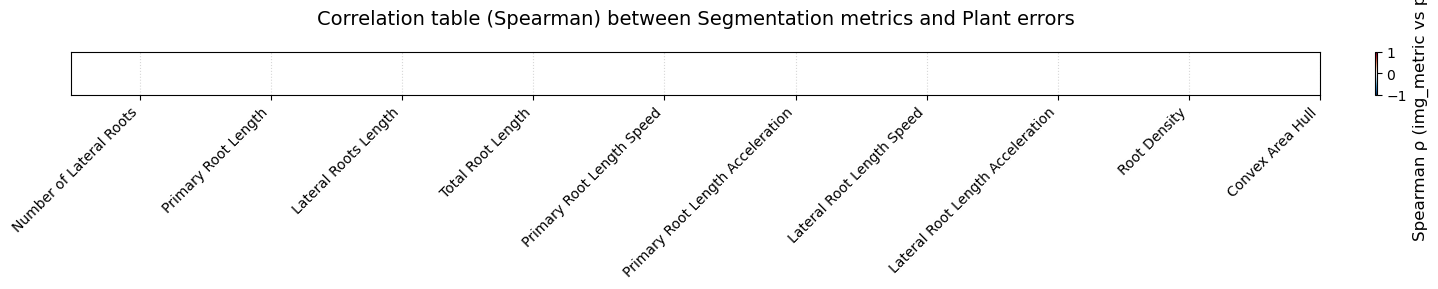

In [ ]:
import numpy as np
from scipy.stats import spearmanr

target_plants = plant_smape_err # plant_rel_err, plant_smape_err, plant_signed_err, plant_ratio

rho_rows, p_rows = [], []
for img_met in img_metrics:
    rho_row, p_row = {}, {}
    for plant_err in target_plants:
        #valid = df_diff_log[[img_met, plant_err]].dropna().copy()
        valid = df_diff_log[[img_met, plant_err]].copy()
        if len(valid) < 3:
            rho, p = np.nan, np.nan
        else:
            valid = valid.replace([np.inf, -np.inf], np.nan).dropna()
            rho, p = spearmanr(valid[img_met].values, valid[plant_err].values)
            # ebisuzaki_correlation_test(valid[img_met].values, valid[plant_err].values, n_surrogates=1000, metric='spearman')
        rho_row[plant_err] = float(rho) if np.isfinite(rho) else np.nan
        p_row[plant_err]   = float(p) if np.isfinite(p) else np.nan
    rho_rows.append(pd.Series(rho_row, name=renaming_dict.get(img_met, img_met)))
    p_rows.append(pd.Series(p_row, name=renaming_dict.get(img_met, img_met)))

CorrSpearman = pd.DataFrame(rho_rows)
Pvalues      = pd.DataFrame(p_rows)

print("ρ Spearman")
display(CorrSpearman.round(3))

print("p-values:")
display(Pvalues.map(lambda x: round(x, 3) if pd.notna(x) else x))
# --- Heatmap simple (matplotlib) centrée sur 0 ---
plt.figure(figsize=(1.2*len(target_plants)+3, 0.45*len(img_metrics)+3))
im = plt.imshow(CorrSpearman.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04, label="Spearman ρ (img_metric vs plant_error)")
plt.yticks(range(len(img_metrics)), [renaming_dict.get(m, m) for m in img_metrics])
plt.xticks(range(len(target_plants)), [renaming_dict.get(m, m) for m in target_plants], rotation=45, ha='right')
plt.title("Correlation table (Spearman) between Segmentation metrics and Plant errors", pad=20)

# Annotations: ρ
for i in range(len(img_metrics)):
    for j in range(len(target_plants)):
        rho = CorrSpearman.iat[i, j]
        p = Pvalues.iat[i, j]
        txt = "" if np.isnan(rho) else f"{rho:.3f}\n(p={p:.3f})"
        plt.text(j, i, txt, ha='center', va='center', fontsize=8, color="black")
plt.tight_layout()
plt.savefig("corr_img_to_plant_error_spearman.png", transparent=True, dpi=600)
plt.show()

# Option: export CSV
#CorrSpearman.to_csv("corr_img_to_plant_error_spearman.csv")
#Pvalues.to_csv("corr_img_to_plant_error_spearman_pvalues.csv")

### Logs x epoch-wise mean SMAPE

ρ Spearman


""


p-values:


""


/tmp/ipykernel_187825/3343546236.py:32: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im = plt.imshow(CorrSpearman.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
/tmp/ipykernel_187825/3343546236.py:32: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  im = plt.imshow(CorrSpearman.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)


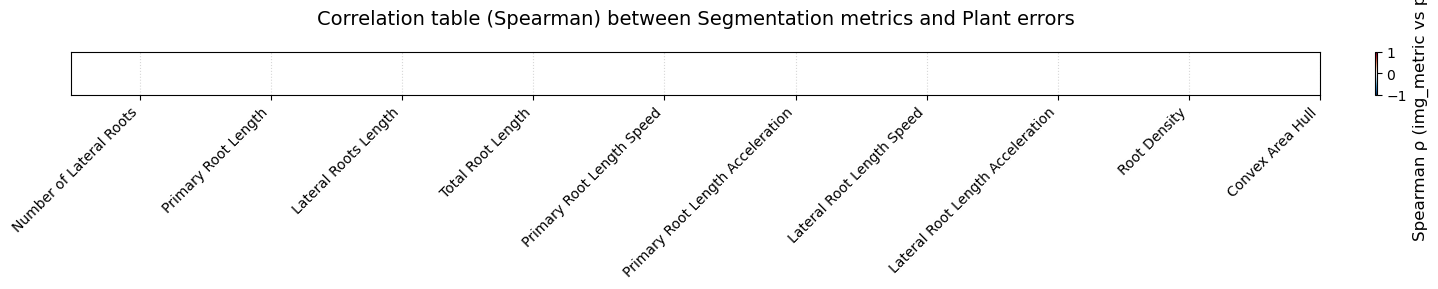

In [ ]:
import numpy as np
from scipy.stats import spearmanr

target_plants = plant_smape_err # plant_rel_err, plant_smape_err, plant_signed_err, plant_ratio

rho_rows, p_rows = [], []
for img_met in img_metrics:
    rho_row, p_row = {}, {}
    for plant_err in target_plants:
        valid = df_diff_log_epoch_mean[[img_met, plant_err]].copy()
        if len(valid) < 3:
            rho, p = np.nan, np.nan
        else:
            valid = valid.replace([np.inf, -np.inf], np.nan).dropna()
            rho, p = spearmanr(valid[img_met].values, valid[plant_err].values)
            # ebisuzaki_correlation_test(valid[img_met].values, valid[plant_err].values, n_surrogates=1000, metric='spearman')
        rho_row[plant_err] = float(rho) if np.isfinite(rho) else np.nan
        p_row[plant_err]   = float(p) if np.isfinite(p) else np.nan
    rho_rows.append(pd.Series(rho_row, name=renaming_dict.get(img_met, img_met)))
    p_rows.append(pd.Series(p_row, name=renaming_dict.get(img_met, img_met)))

CorrSpearman = pd.DataFrame(rho_rows)
Pvalues      = pd.DataFrame(p_rows)

print("ρ Spearman")
display(CorrSpearman.round(3))

print("p-values:")
display(Pvalues.map(lambda x: round(x, 3) if pd.notna(x) else x))
# --- Heatmap simple (matplotlib) centrée sur 0 ---
plt.figure(figsize=(1.2*len(target_plants)+3, 0.45*len(img_metrics)+3))
im = plt.imshow(CorrSpearman.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04, label="Spearman ρ (img_metric vs plant_error)")
plt.yticks(range(len(img_metrics)), [renaming_dict.get(m, m) for m in img_metrics])
plt.xticks(range(len(target_plants)), [renaming_dict.get(m, m) for m in target_plants], rotation=45, ha='right')
plt.title("Correlation table (Spearman) between Segmentation metrics and Plant errors", pad=20)

# Annotations: ρ
for i in range(len(img_metrics)):
    for j in range(len(target_plants)):
        rho = CorrSpearman.iat[i, j]
        p = Pvalues.iat[i, j]
        txt = "" if np.isnan(rho) else f"{rho:.3f}\n(p={p:.3f})"
        plt.text(j, i, txt, ha='center', va='center', fontsize=8, color="black")
plt.tight_layout()
plt.savefig("corr_img_to_plant_error_spearman.png", transparent=True, dpi=600)
plt.show()

# Option: export CSV
#CorrSpearman.to_csv("corr_img_to_plant_error_spearman.csv")
#Pvalues.to_csv("corr_img_to_plant_error_spearman_pvalues.csv")

### $\Delta_{Logs}$ \ $\Delta_{Loss}$ x $\Delta_{SMAPE}$ \ $\Delta_{Loss}$ 

ρ Spearman


""


p-values:


""


/tmp/ipykernel_187825/3561159752.py:33: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im = plt.imshow(CorrSpearman.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
/tmp/ipykernel_187825/3561159752.py:33: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  im = plt.imshow(CorrSpearman.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)


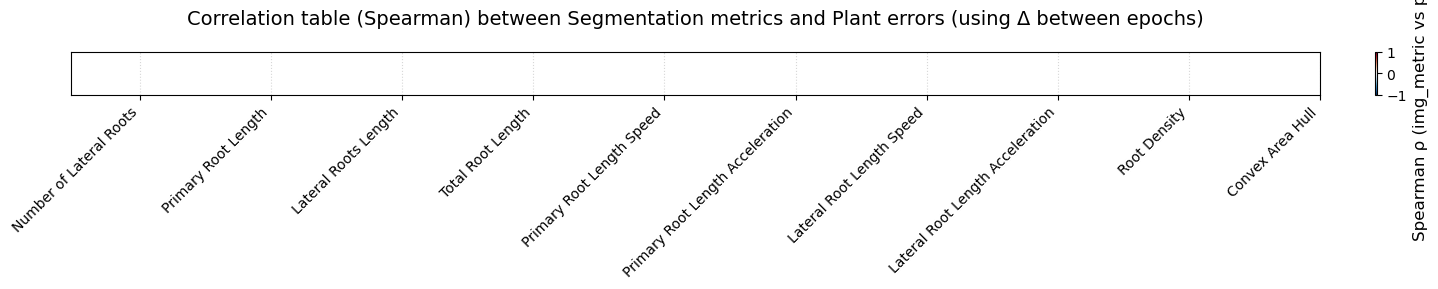

In [ ]:
import numpy as np
from scipy.stats import spearmanr

target_plants = plant_smape_err # plant_rel_err, plant_smape_err, plant_signed_err, plant_ratio

rho_rows, p_rows = [], []
for img_met in img_metrics:
    rho_row, p_row = {}, {}
    for plant_err in target_plants:
        #valid = df_diff_log[[img_met, plant_err]].dropna().copy()
        valid = df_diff_delta_over_loss[[img_met, plant_err]].copy()
        if len(valid) < 3:
            rho, p = np.nan, np.nan
        else:
            valid = valid.replace([np.inf, -np.inf], np.nan).dropna()
            rho, p = spearmanr(valid[img_met].values, valid[plant_err].values)
            # ebisuzaki_correlation_test(valid[img_met].values, valid[plant_err].values, n_surrogates=1000, metric='spearman')
        rho_row[plant_err] = float(rho) if np.isfinite(rho) else np.nan
        p_row[plant_err]   = float(p) if np.isfinite(p) else np.nan
    rho_rows.append(pd.Series(rho_row, name=renaming_dict.get(img_met, img_met)))
    p_rows.append(pd.Series(p_row, name=renaming_dict.get(img_met, img_met)))

CorrSpearman = pd.DataFrame(rho_rows)
Pvalues      = pd.DataFrame(p_rows)

print("ρ Spearman")
display(CorrSpearman.round(3))

print("p-values:")
display(Pvalues.map(lambda x: round(x, 3) if pd.notna(x) else x))
# --- Heatmap simple (matplotlib) centrée sur 0 ---
plt.figure(figsize=(1.2*len(target_plants)+3, 0.45*len(img_metrics)+3))
im = plt.imshow(CorrSpearman.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04, label="Spearman ρ (img_metric vs plant_error)")
plt.yticks(range(len(img_metrics)), [renaming_dict.get(m, m) for m in img_metrics])
plt.xticks(range(len(target_plants)), [renaming_dict.get(m, m) for m in target_plants], rotation=45, ha='right')
plt.title('Correlation table (Spearman) between Segmentation metrics and Plant errors (using Δ between epochs)', pad=20)

# Annotations: ρ
for i in range(len(img_metrics)):
    for j in range(len(target_plants)):
        rho = CorrSpearman.iat[i, j]
        p = Pvalues.iat[i, j]
        txt = "" if np.isnan(rho) else f"{rho:.3f}\n(p={p:.3f})"
        plt.text(j, i, txt, ha='center', va='center', fontsize=8, color="black")
plt.tight_layout()
plt.savefig("corr_img_to_plant_error_spearman_delta.png", transparent=True, dpi=600)
plt.show()

# Option: export CSV
#CorrSpearman.to_csv("corr_img_to_plant_error_spearman.csv")
#Pvalues.to_csv("corr_img_to_plant_error_spearman_pvalues.csv")

### $\Delta_{Logs}$ \ $\Delta_{Loss}$ x epoch-wise mean $\Delta_{SMAPE}$ \ $\Delta_{Loss}$ 

ρ Spearman


""


p-values:


""


/tmp/ipykernel_187825/46242701.py:33: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im = plt.imshow(CorrSpearman.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
/tmp/ipykernel_187825/46242701.py:33: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  im = plt.imshow(CorrSpearman.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)


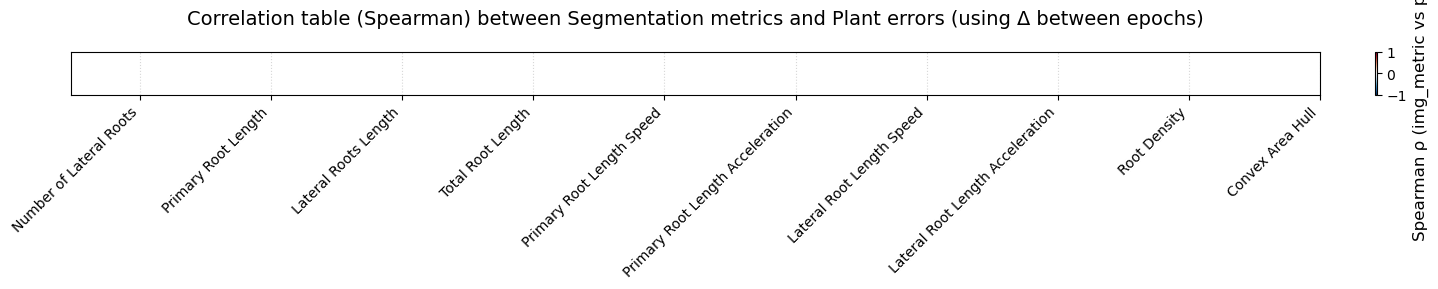

In [ ]:
import numpy as np
from scipy.stats import spearmanr

target_plants = plant_smape_err # plant_rel_err, plant_smape_err, plant_signed_err, plant_ratio

rho_rows, p_rows = [], []
for img_met in img_metrics:
    rho_row, p_row = {}, {}
    for plant_err in target_plants:
        #valid = df_diff_log[[img_met, plant_err]].dropna().copy()
        valid = df_diff_mean_delta_over_loss[[img_met, plant_err]].copy()
        if len(valid) < 3:
            rho, p = np.nan, np.nan
        else:
            valid = valid.replace([np.inf, -np.inf], np.nan).dropna()
            rho, p = spearmanr(valid[img_met].values, valid[plant_err].values)
            # ebisuzaki_correlation_test(valid[img_met].values, valid[plant_err].values, n_surrogates=1000, metric='spearman')
        rho_row[plant_err] = float(rho) if np.isfinite(rho) else np.nan
        p_row[plant_err]   = float(p) if np.isfinite(p) else np.nan
    rho_rows.append(pd.Series(rho_row, name=renaming_dict.get(img_met, img_met)))
    p_rows.append(pd.Series(p_row, name=renaming_dict.get(img_met, img_met)))

CorrSpearman = pd.DataFrame(rho_rows)
Pvalues      = pd.DataFrame(p_rows)

print("ρ Spearman")
display(CorrSpearman.round(3))

print("p-values:")
display(Pvalues.map(lambda x: round(x, 3) if pd.notna(x) else x))
# --- Heatmap simple (matplotlib) centrée sur 0 ---
plt.figure(figsize=(1.2*len(target_plants)+3, 0.45*len(img_metrics)+3))
im = plt.imshow(CorrSpearman.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04, label="Spearman ρ (img_metric vs plant_error)")
plt.yticks(range(len(img_metrics)), [renaming_dict.get(m, m) for m in img_metrics])
plt.xticks(range(len(target_plants)), [renaming_dict.get(m, m) for m in target_plants], rotation=45, ha='right')
plt.title('Correlation table (Spearman) between Segmentation metrics and Plant errors (using Δ between epochs)', pad=20)

# Annotations: ρ
for i in range(len(img_metrics)):
    for j in range(len(target_plants)):
        rho = CorrSpearman.iat[i, j]
        p = Pvalues.iat[i, j]
        txt = "" if np.isnan(rho) else f"{rho:.3f}\n(p={p:.3f})"
        plt.text(j, i, txt, ha='center', va='center', fontsize=8, color="black")
plt.tight_layout()
plt.savefig("corr_img_to_plant_error_spearman_delta.png", transparent=True, dpi=600)
plt.show()

# Option: export CSV
#CorrSpearman.to_csv("corr_img_to_plant_error_spearman.csv")
#Pvalues.to_csv("corr_img_to_plant_error_spearman_pvalues.csv")

## Windowed correlations

In [ ]:
window_size = 70
overlap_btw_windows=30

In [ ]:
def correlation_in_windows(df, img_metric, plant_metric, window_begin, window_end, correlation_func=spearmanr):
    window_data = df[(df['epoch'] >= window_begin) & (df['epoch'] < window_end)]
    valid = window_data[[img_metric, plant_metric]].replace([np.inf, -np.inf], np.nan).dropna() # danger ? 
    if len(valid) < 3:
        return np.nan, np.nan
    rho, p = correlation_func(valid[img_metric], valid[plant_metric])
    return float(rho), float(p)

def rolling_correlation(df, img_metric, plant_metric, window_size, overlap):
    max_epoch = df['epoch'].max()
    step = window_size - overlap
    windows = []
    for start in range(0, max_epoch, step):
        end = start + window_size
        rho, p = correlation_in_windows(df, img_metric, plant_metric, start, end)
        windows.append({'window_start': start, 'window_end': end, 'rho': rho, 'p_value': p})
    return pd.DataFrame(windows)

img_metric_example = img_metrics[0]
plant_metric_example = plant_smape_err[0]
df_corr_windows = rolling_correlation(df_diff_log_epoch_mean, img_metric_example, plant_metric_example, window_size, overlap_btw_windows)
print(f"Rolling correlation between {img_metric_example} and {plant_metric_example}:")
df_corr_windows.head()

IndexError: list index out of range

In [ ]:
def table_rolling_correlation(df, img_metrics, plant_metrics, window_size, overlap):
    results = []
    for img_metric in img_metrics:
        for plant_metric in plant_metrics:
            df_corr_windows = rolling_correlation(df, img_metric, plant_metric, window_size, overlap)
            df_corr_windows['img_metric'] = img_metric
            df_corr_windows['plant_metric'] = plant_metric
            results.append(df_corr_windows)
    return pd.concat(results, ignore_index=True)

df_all_corr = table_rolling_correlation(df_diff_log_epoch_mean, img_metrics, target_plants, window_size, overlap_btw_windows)
print("Rolling correlations for all metric pairs:")
df_all_corr.head()

In [ ]:
# heatmap correelation over the epochs between img_metrics and lateral root length smape error
plt.figure(figsize=(12, 6))
plant_met = 'LateralRootLength_smape_err'
for plant_met in target_plants:
    unique_color_for_each_img_metric = {img_metric: plt.cm.tab20(i) for i, img_metric in enumerate(img_metrics)}
    for img_metric in img_metrics:
        df_plot = df_all_corr[df_all_corr['plant_metric'] == plant_met]
        df_plot = df_plot[df_plot['img_metric'] == img_metric]
        plt.plot(df_plot['window_start'], df_plot['rho'], label=renaming_dict.get(img_metric, img_metric), color=unique_color_for_each_img_metric[img_metric])
    plt.xlabel('Epoch')
    plt.ylabel(f"Spearman ρ with {renaming_dict.get(plant_met, plant_met)}")
    plt.title(f"Rolling Spearman Correlation (window={window_size}, overlap={overlap_btw_windows})")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr

def plot_rolling_correlation(df, target_plant_metric, img_metrics_list, window_size=20, step=20, method='spearman', renaming_dict=None):
    """
    Calcule et affiche l'évolution de la corrélation entre une métrique plante cible 
    et une liste de métriques d'images, sur des fenêtres d'epochs (basées sur la vraie valeur de l'epoch).
    """
    min_epoch = int(df['epoch'].min())
    max_epoch = int(df['epoch'].max())
    
    results = []
    window_labels = []
    
    for start_ep in range(min_epoch, max_epoch, step):
        end_ep = start_ep + window_size
        
        window_df = df[(df['epoch'] >= start_ep) & (df['epoch'] < end_ep)]
        
        if window_df.empty:
            continue
            
        label = f"Ep {start_ep}-{end_ep-1}"
        window_labels.append(label)
        
        corrs = {}
        for img_m in img_metrics_list:
            # Nettoyage des NaNs et infinis pour la fenêtre actuelle
            valid = window_df[[img_m, target_plant_metric]].replace([np.inf, -np.inf], np.nan).dropna()
            
            # Il faut un minimum de points significatif (ex: 10 pour être robuste)
            if len(valid) >= 10:
                # print(number of points)
                print(f"Calcul de la corrélation pour {img_m} vs {target_plant_metric} dans la fenêtre {label} avec {len(valid)} points.")
                if method == 'spearman':
                    corr, _ = spearmanr(valid[img_m], valid[target_plant_metric])
                else:
                    corr, _ = pearsonr(valid[img_m], valid[target_plant_metric])
            else:
                corr = np.nan
                
            corrs[img_m] = corr
            
        results.append(corrs)
        
    # 3. Formatage en DataFrame pour Seaborn
    corr_df = pd.DataFrame(results, index=window_labels).T
    
    # Application propre du dictionnaire de renommage
    if renaming_dict is not None:
        corr_df.index = [renaming_dict.get(m, m) for m in corr_df.index]
    
    # On retire les colonnes (fenêtres) qui n'ont pu calculer aucune corrélation
    corr_df = corr_df.dropna(how='all', axis=1)
    
    # 4. Visualisation (Heatmap Évolutive)
    plt.figure(figsize=(max(10, len(corr_df.columns) * 1.2), max(6, len(img_metrics_list) * 0.45)))
    
    ax = sns.heatmap(
        corr_df, 
        annot=True,          
        fmt=".2f",           
        cmap='RdBu_r',       
        center=0,            
        vmin=-1, vmax=1,     
        cbar_kws={'label': f'Corrélation {method.capitalize()}'},
        linewidths=0.5,
        annot_kws={"size": 10}
    )
    
    plt.title(f"Evolution of Correlation ({method.capitalize()}) between Segmentation Metrics and {renaming_dict.get(target_plant_metric, target_plant_metric)}",
              fontsize=14, fontweight='bold', pad=20)
    plt.xlabel("Epoch Windows", fontsize=12)
    plt.ylabel("Segmentation Metrics", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
    
    return corr_df

metric_cible = 'TotalRootLength_smape_err'

print(f"Génération de la matrice de corrélation pour {metric_cible}...")

df_rolling_corr = plot_rolling_correlation(
    df=df_diff_log,
    target_plant_metric=metric_cible, 
    img_metrics_list=img_metrics, 
    window_size=70,    # L'intervalle de temps d'une fenêtre (ex: 20 epochs)
    step=30,           # Le pas de déplacement (20 = pas de chevauchement)
    method='spearman',     # ou 'pearson'
    renaming_dict=renaming_dict
)

In [ ]:
# unique model and loss values
print("Unique model values:", df_diff_log['model'].unique())
print("Unique loss values:", df_diff_log['loss'].unique())

In [ ]:
metric_cible = 'TotalRootLength_smape_err'

print(f"Génération de la matrice de corrélation pour {metric_cible}...")

df_rolling_corr = plot_rolling_correlation(
    df=df_diff_log[df_diff_log['loss'] == 'cldice_dice'],
    target_plant_metric=metric_cible, 
    img_metrics_list=img_metrics, 
    window_size=70,    # L'intervalle de temps d'une fenêtre (ex: 20 epochs)
    step=30,           # Le pas de déplacement (20 = pas de chevauchement)
    method='spearman',     # ou 'pearson'
    renaming_dict=renaming_dict
)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr

def plot_rolling_correlation(df, target_plant_metric, img_metrics_list, window_size=20, step=20, method='spearman', renaming_dict=None):
    """
    Calcule et affiche l'évolution de la corrélation entre une métrique plante cible 
    et une liste de métriques d'images, sur des fenêtres d'epochs (basées sur la vraie valeur de l'epoch).
    """
    # 1. Identifier la plage d'époques totale
    min_epoch = int(df['epoch'].min())
    max_epoch = int(df['epoch'].max())
    
    results = []
    window_labels = []
    
    # 2. Boucle sur les valeurs d'epochs (ex: de 10 à 200, par pas de 20)
    for start_ep in range(min_epoch, max_epoch, step):
        end_ep = start_ep + window_size
        
        # SÉLECTION DES DONNÉES BRUTES (basée sur la valeur de l'epoch)
        # On inclut start_ep (>=) et on exclut end_ep (<) pour éviter de compter une epoch en double
        window_df = df[(df['epoch'] >= start_ep) & (df['epoch'] < end_ep)]
        
        # Si la fenêtre ne contient aucune donnée, on passe à la suivante
        if window_df.empty:
            continue
            
        # Création du label pour l'axe X (ex: "Ep 10-29")
        label = f"Ep {start_ep}-{end_ep-1}"
        window_labels.append(label)
        
        corrs = {}
        for img_m in img_metrics_list:
            # Nettoyage des NaNs et infinis pour la fenêtre actuelle
            valid = window_df[[img_m, target_plant_metric]].replace([np.inf, -np.inf], np.nan).dropna()
            
            # Il faut un minimum de points significatif (ex: 10 pour être robuste)
            if len(valid) >= 10:
                # print(number of points)
                print(f"Calcul de la corrélation pour {img_m} vs {target_plant_metric} dans la fenêtre {label} avec {len(valid)} points.")
                if method == 'spearman':
                    corr, _ = spearmanr(valid[img_m], valid[target_plant_metric])
                else:
                    corr, _ = pearsonr(valid[img_m], valid[target_plant_metric])
            else:
                corr = np.nan
                
            corrs[img_m] = corr
            
        results.append(corrs)
        
    # 3. Formatage en DataFrame pour Seaborn
    corr_df = pd.DataFrame(results, index=window_labels).T
    
    # Application propre du dictionnaire de renommage
    if renaming_dict is not None:
        corr_df.index = [renaming_dict.get(m, m) for m in corr_df.index]
    
    # On retire les colonnes (fenêtres) qui n'ont pu calculer aucune corrélation
    corr_df = corr_df.dropna(how='all', axis=1)
    
    # 4. Visualisation (Heatmap Évolutive)
    plt.figure(figsize=(max(10, len(corr_df.columns) * 1.2), max(6, len(img_metrics_list) * 0.45)))
    
    ax = sns.heatmap(
        corr_df, 
        annot=True,          
        fmt=".2f",           
        cmap='RdBu_r',       
        center=0,            
        vmin=-1, vmax=1,     
        cbar_kws={'label': f'Corrélation {method.capitalize()}'},
        linewidths=0.5,
        annot_kws={"size": 10}
    )
    
    plt.title(f"Evolution of Correlation ({method.capitalize()}) between Segmentation Metrics and {renaming_dict.get(target_plant_metric, target_plant_metric)}",
              fontsize=14, fontweight='bold', pad=20)
    plt.xlabel("Epoch Windows", fontsize=12)
    plt.ylabel("Segmentation Metrics", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
    
    return corr_df

# --- Exemple d'utilisation ---
# Pour des fenêtres de [10 à 30[, [30 à 50[, [50 à 70[, etc. :
# Réglez window_size = 20 et step = 20 (step détermine le décalage, s'il est égal à la window, elles ne se chevauchent pas)

metric_cible = 'TotalRootLength_smape_err'

print(f"Génération de la matrice de corrélation pour {metric_cible}...")

df_rolling_corr = plot_rolling_correlation(
    df=df_diff_log,
    target_plant_metric=metric_cible, 
    img_metrics_list=img_metrics, 
    window_size=50,    # L'intervalle de temps d'une fenêtre (ex: 20 epochs)
    step=10,           # Le pas de déplacement (20 = pas de chevauchement)
    method='spearman',     # ou 'pearson'
    renaming_dict=renaming_dict
)